## Step:0 Load and datset overview

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats
from ta.momentum import (RSIIndicator, StochasticOscillator,ROCIndicator, WilliamsRIndicator)
from ta.trend   import (MACD, CCIIndicator, SMAIndicator,EMAIndicator, ADXIndicator)
from ta.volatility import BollingerBands, AverageTrueRange
from ta.volume     import OnBalanceVolumeIndicator

# Resetting the dataframe path to the original file for future use
new_path = r"E:\Stock-Price-Prediction-using-Advanced-modelling\data\2_data\filter_OHLCV.parquet"
df = pd.read_parquet(new_path)
df.columns = df.columns.str.lower()
df

,symbol,date,open,high,low,close,volume
0,BRK-B,2016-01-08,130.110001,130.399994,128.210007,128.330002,6101600
1,BRK-B,2016-01-13,128.970001,129.380005,125.709999,126.250000,6042400
2,BRK-B,2016-01-15,125.339996,126.809998,124.510002,126.139999,8145100
3,BRK-B,2016-01-29,126.660004,129.770004,126.110001,129.770004,6523800
4,BRK-B,2016-02-03,126.339996,126.629997,123.550003,126.239998,6607500
...,...,...,...,...,...,...,...
1220273,VICI,2020-07-02,15.681162,15.740225,15.260340,15.400615,4136400
1220274,VICI,2020-07-06,15.799288,15.865734,14.902272,14.928112,4423500
1220275,VICI,2020-07-07,14.691864,15.105303,14.573738,14.758309,2779800
1220276,VICI,2020-07-08,14.809990,14.950265,14.621728,14.913351,2158800


In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1220278 entries, 0 to 1220277
Data columns (total 7 columns):
 #   Column  Non-Null Count    Dtype         
---  ------  --------------    -----         
 0   symbol  1220278 non-null  str           
 1   date    1220278 non-null  datetime64[ms]
 2   open    1220278 non-null  float64       
 3   high    1220278 non-null  float64       
 4   low     1220278 non-null  float64       
 5   close   1220278 non-null  float64       
 6   volume  1220278 non-null  int64         
dtypes: datetime64[ms](1), float64(4), int64(1), str(1)
memory usage: 68.9 MB


In [63]:
# Basic info about the dataset
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nDate range:", df['date'].min(), "→", df['date'].max())
print("Unique stocks:", df['symbol'].nunique())
print("Total trading days per stock (avg):", round(df.groupby('symbol').size().mean(), 1))

Shape: (1220278, 7)

Columns: ['symbol', 'date', 'open', 'high', 'low', 'close', 'volume']

Dtypes:
 symbol               str
date      datetime64[ms]
open             float64
high             float64
low              float64
close            float64
volume             int64
dtype: object

Date range: 2016-01-04 00:00:00 → 2025-12-31 00:00:00
Unique stocks: 500
Total trading days per stock (avg): 2440.6


## Step:1 Feature Analysis(Base Research Paper)

In [64]:
# group by ticker and date in ascending order
df = df.sort_values(["symbol", "date"], ascending=[True, True]).reset_index(drop=True)
print(f"Sorted: {df.shape[0]:,} rows | {df['symbol'].nunique()} tickers")

Sorted: 1,220,278 rows | 500 tickers


In [65]:
# Single function to compute all features for a given stock group
def add_all_features(grp: pd.DataFrame) -> pd.DataFrame:
    grp = grp.copy()

    # 1. Price-based features
    grp["Daily_Return"]  = grp["close"].pct_change()
    grp["Overnight_Gap"] = (grp["open"] - grp["close"].shift(1)) / grp["close"].shift(1)
    grp["HL_Range"]      = (grp["high"] - grp["low"]) / grp["close"]
    grp["CO_Spread"]     = (grp["close"] - grp["open"]) / grp["open"]
    grp["Upper_Shadow"]  = (grp["high"] - grp[["open","close"]].max(axis=1)) / grp["close"]
    grp["Lower_Shadow"]  = (grp[["open","close"]].min(axis=1) - grp["low"])  / grp["close"]
    grp["Body_Size"]     = (grp["close"] - grp["open"]).abs() / grp["close"]

    # 2. Moving Averages & Trend
    for w in [5, 10, 20, 50]:
        grp[f"SMA_{w}"] = SMAIndicator(grp["close"], window=w).sma_indicator()

    grp["EMA_12"]        = EMAIndicator(grp["close"], window=12).ema_indicator()
    grp["EMA_26"]        = EMAIndicator(grp["close"], window=26).ema_indicator()
    grp["Price_vs_SMA20"]= grp["close"] / grp["SMA_20"]
    grp["SMA5_vs_SMA20"] = grp["SMA_5"] / grp["SMA_20"]
    grp["EMA_Cross"]     = grp["EMA_12"] - grp["EMA_26"]

    # 3. Momentum & Oscillators
    grp["RSI_14"]     = RSIIndicator(grp["close"], window=14).rsi()

    macd_obj = MACD(grp["close"])
    grp["MACD"]       = macd_obj.macd()
    grp["MACD_Signal"]= macd_obj.macd_signal()
    grp["MACD_Hist"]  = macd_obj.macd_diff()

    stoch = StochasticOscillator(grp["high"], grp["low"], grp["close"])
    grp["Stoch_K"]    = stoch.stoch()
    grp["Stoch_D"]    = stoch.stoch_signal()

    grp["ROC_5"]      = ROCIndicator(grp["close"], window=5).roc()
    grp["ROC_10"]     = ROCIndicator(grp["close"], window=10).roc()
    grp["Williams_R"] = WilliamsRIndicator(grp["high"], grp["low"], grp["close"]).williams_r()
    grp["CCI_20"]     = CCIIndicator(grp["high"], grp["low"], grp["close"], window=20).cci()
    grp["ADX_14"]     = ADXIndicator(grp["high"], grp["low"], grp["close"], window=14).adx()

    # 4. Volatility & Price Action
    grp["ATR_14"]     = AverageTrueRange(grp["high"], grp["low"], grp["close"], window=14).average_true_range()

    bb = BollingerBands(grp["close"], window=20, window_dev=2)
    grp["BB_Upper"]    = bb.bollinger_hband()
    grp["BB_Lower"]    = bb.bollinger_lband()
    grp["BB_Mid"]      = bb.bollinger_mavg()
    grp["BB_Width"]    = (grp["BB_Upper"] - grp["BB_Lower"]) / grp["BB_Mid"]
    grp["BB_Position"] = (grp["close"] - grp["BB_Lower"]) / (grp["BB_Upper"] - grp["BB_Lower"] + 1e-9)

    grp["Rolling_Std_5"]   = grp["Daily_Return"].rolling(5).std()
    grp["Rolling_Std_20"]  = grp["Daily_Return"].rolling(20).std()
    grp["Volatility_Ratio"]= grp["Rolling_Std_5"] / (grp["Rolling_Std_20"] + 1e-9)

    # 5. Volume-based features
    vol_ma = grp["volume"].rolling(20).mean()

    grp["Volume_MA_Ratio"]    = grp["volume"] / (vol_ma + 1e-9)
    grp["OBV"]                = OnBalanceVolumeIndicator(grp["close"], grp["volume"]).on_balance_volume()
    grp["OBV_Signal"]         = grp["OBV"].ewm(span=9).mean()
    grp["Volume_Spike"]       = (grp["volume"] > 2 * vol_ma).astype(int)
    grp["VWAP"]               = (grp["close"] * grp["volume"]).rolling(20).sum() / grp["volume"].rolling(20).sum()
    grp["Price_vs_VWAP"]      = grp["close"] / (grp["VWAP"] + 1e-9)
    grp["Volume_Return_Corr"] = grp["Daily_Return"].rolling(10).corr(grp["volume"].pct_change())

    # 6. Lagged features
    for lag in [1, 2, 3]:
        grp[f"Return_Lag{lag}"] = grp["Daily_Return"].shift(lag)

    grp["Volume_Lag1"] = grp["Volume_MA_Ratio"].shift(1)
    grp["High_Lag1"]   = grp["high"].shift(1)
    grp["Low_Lag1"]    = grp["low"].shift(1)

    # Consecutive up days - safe inside per-stock group
    up = grp["Daily_Return"].gt(0)
    grp["Consecutive_Up"] = (
        up.groupby((up != up.shift()).cumsum()).cumcount() + 1
    ) * up

    grp["Day_of_Week"]  = grp["date"].dt.dayofweek
    grp["Month"]        = grp["date"].dt.month
    grp["Is_Month_End"] = grp["date"].dt.is_month_end.astype(int)

    return grp

# Apply feature engineering per stock group
required_cols = {"symbol", "date", "open", "high", "low", "close", "volume"}
if not required_cols.issubset(df.columns):
    df = pd.read_parquet(new_path)
    df.columns = df.columns.str.lower()
print("Computing features per ticker - this takes ~1-2 min for 500 stocks...")

feature_frames = []
for symbol, grp in df.groupby("symbol", sort=False):
    grp = grp.copy()
    grp["symbol"] = symbol
    feature_frames.append(add_all_features(grp))
df = pd.concat(feature_frames, ignore_index=True)
df = df.sort_values(["symbol", "date"]).reset_index(drop=True)
print(f"Features added: {df.shape[0]:,} rows x {df.shape[1]} columns")
df


Computing features per ticker - this takes ~1-2 min for 500 stocks...
Features added: 1,220,278 rows x 60 columns


,symbol,date,open,high,low,close,volume,Daily_Return,Overnight_Gap,HL_Range,...,Return_Lag1,Return_Lag2,Return_Lag3,Volume_Lag1,High_Lag1,Low_Lag1,Consecutive_Up,Day_of_Week,Month,Is_Month_End
0,A,2016-01-04,37.824543,37.944297,37.161277,37.483696,3287300,NaN,NaN,0.020890,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0
1,A,2016-01-05,37.520545,37.723211,37.161277,37.354729,2587200,-0.003441,0.000983,0.015043,...,NaN,NaN,NaN,NaN,37.944297,37.161277,0,1,1,0
2,A,2016-01-06,37.069159,37.760060,36.894129,37.520546,2103600,0.004439,-0.007645,0.023079,...,-0.003441,NaN,NaN,NaN,37.723211,37.161277,1,2,1,0
3,A,2016-01-07,36.977030,36.986244,35.751834,35.926861,3504300,-0.042475,-0.014486,0.034359,...,0.004439,-0.003441,NaN,NaN,37.760060,36.894129,0,3,1,0
4,A,2016-01-08,36.129522,36.580908,35.438621,35.549164,3736700,-0.010513,0.005641,0.032133,...,-0.042475,0.004439,-0.003441,NaN,36.986244,35.751834,0,4,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1220273,ZTS,2025-12-24,122.045745,124.613567,122.006086,124.415276,2369000,0.015784,-0.003562,0.020958,...,-0.001939,0.012598,-0.004236,0.780559,122.918214,121.411227,1,2,12,0
1220274,ZTS,2025-12-26,124.088098,125.238159,123.731180,125.148933,3226800,0.005897,-0.002630,0.012041,...,0.015784,-0.001939,0.012598,0.384482,124.613567,122.006086,2,4,12,0
1220275,ZTS,2025-12-29,125.079544,125.763629,124.484676,124.901085,4465600,-0.001980,-0.000554,0.010240,...,0.005897,0.015784,-0.001939,0.523582,125.238159,123.731180,0,0,12,0
1220276,ZTS,2025-12-30,124.474765,126.507204,124.375615,125.327400,3230200,0.003413,-0.003413,0.017008,...,-0.001980,0.005897,0.015784,0.711189,125.763629,124.484676,1,1,12,0


In [66]:
df.isnull().sum()

symbol                    0
date                      0
open                      0
high                      0
low                       0
close                     0
volume                    0
Daily_Return            500
Overnight_Gap           500
HL_Range                  0
CO_Spread                 0
Upper_Shadow              0
Lower_Shadow              0
Body_Size                 0
SMA_5                  2000
SMA_10                 4500
SMA_20                 9500
SMA_50                24497
EMA_12                 5500
EMA_26                12500
Price_vs_SMA20         9500
SMA5_vs_SMA20          9500
EMA_Cross             12500
RSI_14                 6500
MACD                  12500
MACD_Signal           16500
MACD_Hist             16500
Stoch_K                6731
Stoch_D                7781
ROC_5                  2500
ROC_10                 5000
Williams_R             6731
CCI_20                 9629
ADX_14                    0
ATR_14                    0
BB_Upper            

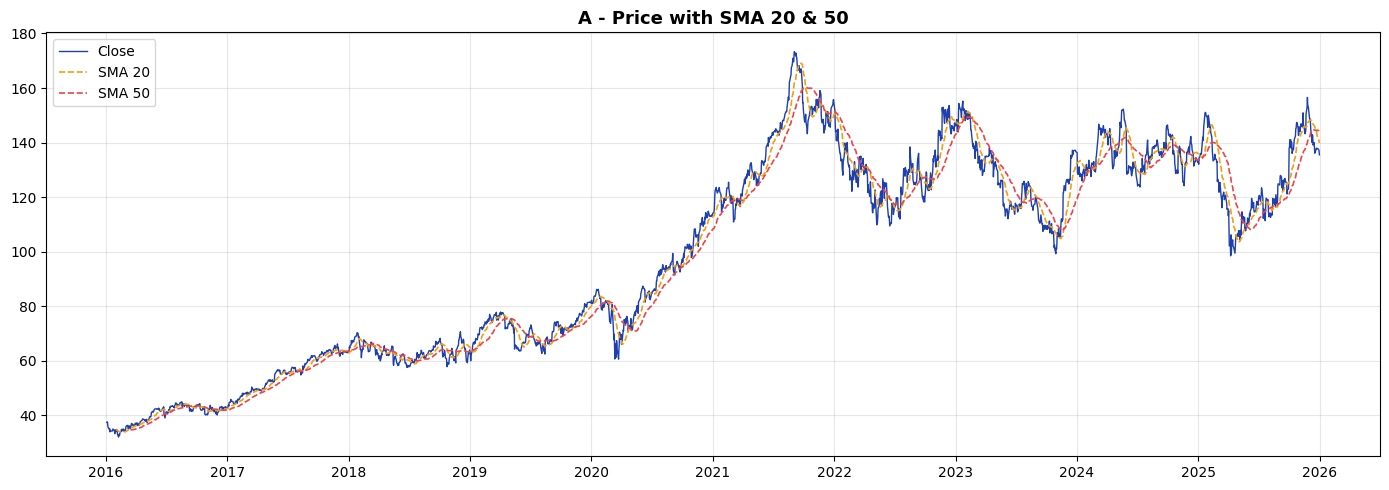

In [67]:
# Pick one stock for visualization
SAMPLE_TICKER = df["symbol"].iloc[0]
s = df[df["symbol"] == SAMPLE_TICKER].copy()

# Moving Averages
plt.figure(figsize=(14, 5))
plt.plot(s["date"], s["close"],   label="Close",  linewidth=1,   color="#1e40af")
plt.plot(s["date"], s["SMA_20"],  label="SMA 20", linewidth=1.2, color="#f59e0b", linestyle="--")
plt.plot(s["date"], s["SMA_50"],  label="SMA 50", linewidth=1.2, color="#ef4444", linestyle="--")
plt.title(f"{SAMPLE_TICKER} - Price with SMA 20 & 50", fontsize=13, fontweight="bold")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


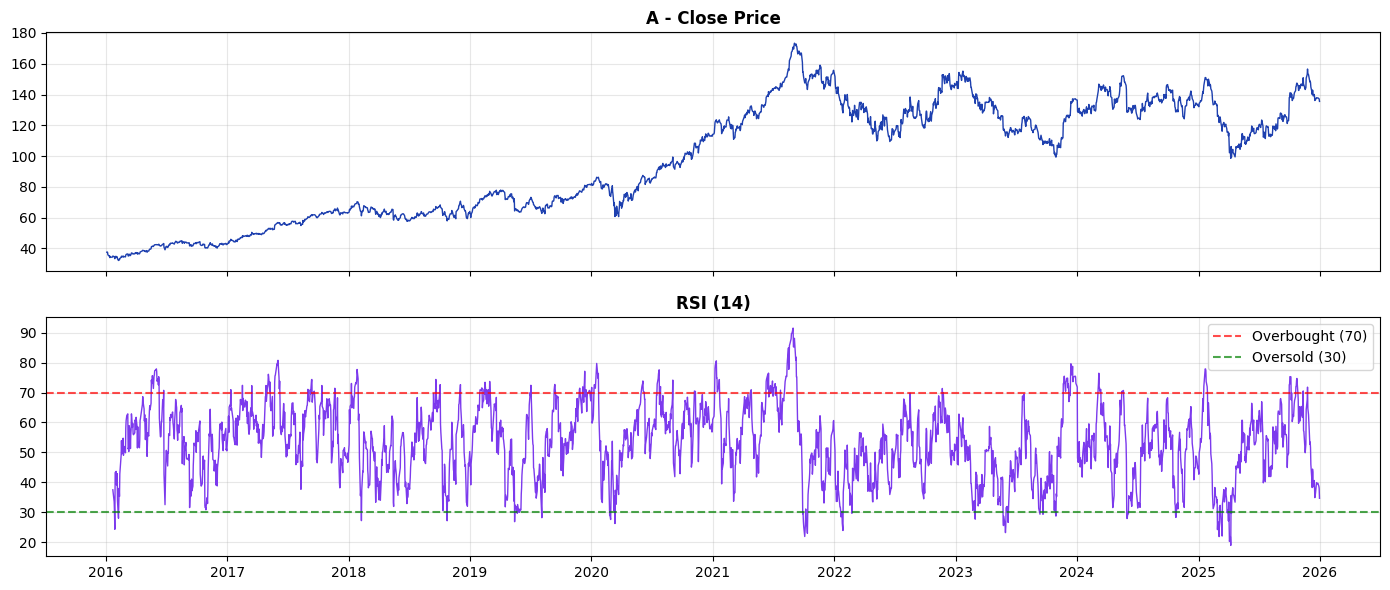

In [68]:
# RSI
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(s["date"], s["close"], color="#1e40af", linewidth=1)
axes[0].set_title(f"{SAMPLE_TICKER} - Close Price", fontweight="bold")
axes[0].grid(True, alpha=0.3)

axes[1].plot(s["date"], s["RSI_14"], color="#7c3aed", linewidth=1)
axes[1].axhline(70, color="red",   linestyle="--", alpha=0.7, label="Overbought (70)")
axes[1].axhline(30, color="green", linestyle="--", alpha=0.7, label="Oversold (30)")
axes[1].set_title("RSI (14)", fontweight="bold")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

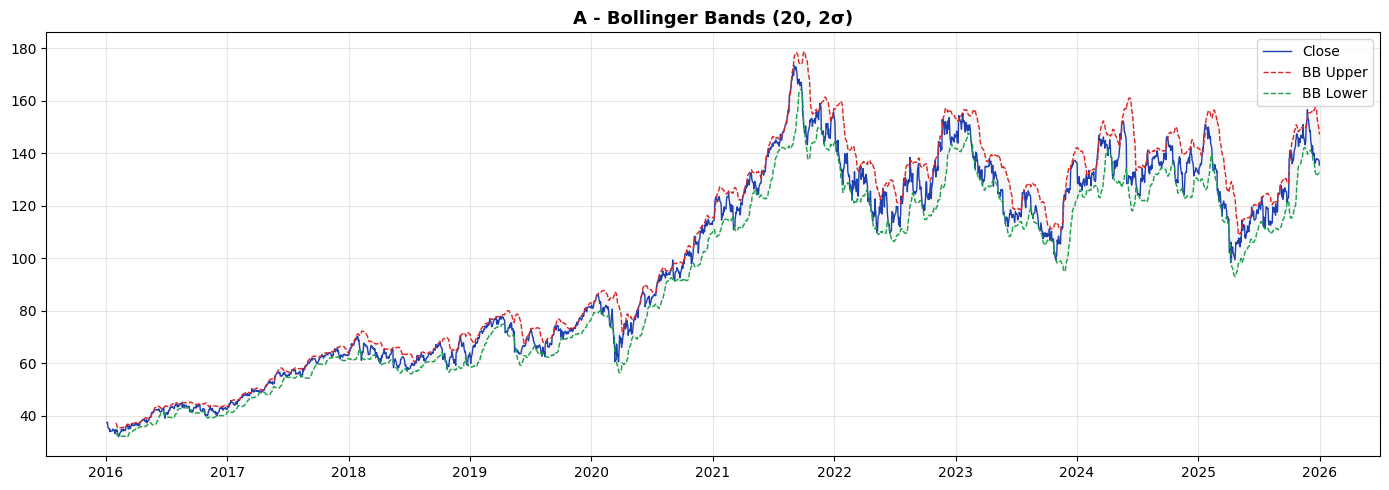

In [69]:
# Bollinger Bands
plt.figure(figsize=(14, 5))
plt.plot(s["date"], s["close"],    label="Close",    color="#1e40af", linewidth=1)
plt.plot(s["date"], s["BB_Upper"], label="BB Upper", color="#dc2626", linewidth=1, linestyle="--")
plt.plot(s["date"], s["BB_Lower"], label="BB Lower", color="#16a34a", linewidth=1, linestyle="--")
plt.fill_between(s["date"], s["BB_Lower"], s["BB_Upper"], alpha=0.07, color="gray")
plt.title(f"{SAMPLE_TICKER} - Bollinger Bands (20, 2σ)", fontsize=13, fontweight="bold")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [70]:
print(f"Volume spikes detected across all stocks: {df['Volume_Spike'].sum():,}")

Volume spikes detected across all stocks: 39,344


## Step:2 Descriptive Statistics

In [71]:
# 2.1 Overall descriptive statistics for numeric columns
desc = df[['open', 'high', 'low', 'close', 'volume']].describe().T
desc['median'] = df[['open', 'high', 'low', 'close', 'volume']].median()
desc['skewness'] = df[['open', 'high', 'low', 'close', 'volume']].skew()
desc['kurtosis'] = df[['open', 'high', 'low', 'close', 'volume']].kurtosis()
print(desc.round(4))

            count          mean           std     min           25%  \
open    1220278.0  1.291075e+02  2.701225e+02  0.6044  4.132850e+01   
high    1220278.0  1.305998e+02  2.733323e+02  0.6234  4.180040e+01   
low     1220278.0  1.275897e+02  2.670019e+02  0.6037  4.084200e+01   
close   1220278.0  1.291225e+02  2.701622e+02  0.6151  4.133420e+01   
volume  1220278.0  6.553134e+06  2.734128e+07  0.0000  1.022400e+06   

                 50%           75%           max        median  skewness  \
open    7.692130e+01  1.445747e+02  9.914170e+03  7.692130e+01   16.8218   
high    7.780520e+01  1.462170e+02  9.964770e+03  7.780520e+01   16.8095   
low     7.602860e+01  1.429289e+02  9.794000e+03  7.602860e+01   16.8411   
close   7.692330e+01  1.445894e+02  9.924400e+03  7.692330e+01   16.8152   
volume  2.191900e+06  5.073200e+06  3.692928e+09  2.191900e+06   24.5832   

         kurtosis  
open     402.6240  
high     401.7632  
low      403.5868  
close    402.1954  
volume  1121.516

In [72]:
# 2.2 Engineered feature descriptive stats (grouped by category)
price_feats  = ['Daily_Return', 'Overnight_Gap', 'HL_Range', 'CO_Spread',
                'Upper_Shadow', 'Lower_Shadow', 'Body_Size']
trend_feats  = ['Price_vs_SMA20', 'SMA5_vs_SMA20', 'EMA_Cross']
mom_feats    = ['RSI_14', 'MACD', 'MACD_Hist', 'Stoch_K', 'ROC_5', 'ROC_10',
                'Williams_R', 'CCI_20', 'ADX_14']
vol_feats    = ['ATR_14', 'BB_Width', 'BB_Position', 'Rolling_Std_5',
                'Rolling_Std_20', 'Volatility_Ratio']
volume_feats = ['Volume_MA_Ratio', 'Volume_Return_Corr', 'Price_vs_VWAP']

for label, cols in [('Price-based', price_feats), ('Trend', trend_feats),
                    ('Momentum', mom_feats), ('Volatility', vol_feats),
                    ('Volume', volume_feats)]:
    print("")
    print("")
    print(f"\n{label} Features")
    print(df[cols].describe().T[['mean','std','min','50%','max']].round(4))




Price-based Features
                 mean     std     min     50%     max
Daily_Return   0.0007  0.0212 -0.5386  0.0008  0.7459
Overnight_Gap  0.0005  0.0124 -0.4764  0.0005  0.8109
HL_Range       0.0238  0.0168  0.0000  0.0196  1.2127
CO_Spread      0.0003  0.0172 -0.5007  0.0004  0.7658
Upper_Shadow   0.0059  0.0066 -0.0000  0.0043  0.5775
Lower_Shadow   0.0062  0.0068 -0.0012  0.0046  0.3254
Body_Size      0.0117  0.0126  0.0000  0.0082  1.0028



Trend Features
                  mean     std       min     50%       max
Price_vs_SMA20  1.0056  0.0502    0.1893  1.0070    1.9536
SMA5_vs_SMA20   1.0042  0.0393    0.3057  1.0055    1.6497
EMA_Cross       0.4730  5.5899 -422.0713  0.2463  263.2760



Momentum Features
               mean       std       min      50%       max
RSI_14      52.8877   12.2122    0.0000  53.0926   99.8630
MACD         0.4730    5.5899 -422.0713   0.2463  263.2760
MACD_Hist    0.0026    1.6544 -176.0427   0.0065   99.5544
Stoch_K     55.5477   30.1741   -

In [73]:
# 2.3 Per-symbol stats using engineered features
symbol_stats = df.groupby('symbol').agg(
    avg_close        = ('close',           'mean'),
    std_close        = ('close',           'std'),
    avg_volume       = ('volume',          'mean'),
    trading_days     = ('date',            'count'),
    avg_daily_return = ('Daily_Return',    'mean'),
    avg_volatility   = ('Rolling_Std_20',  'mean'),
    avg_rsi          = ('RSI_14',          'mean'),
    avg_adx          = ('ADX_14',          'mean'),
    vol_spike_pct    = ('Volume_Spike',    'mean'),
).sort_values('avg_close', ascending=False)

print("Top 10 highest avg-price stocks:")
print(symbol_stats.head(10).round(4))
print("\nTop 10 most traded stocks:")
print(symbol_stats.sort_values('avg_volume', ascending=False).head(10).round(4))
print("\nTop 10 most volatile stocks (Rolling Std 20):")
print(symbol_stats.sort_values('avg_volatility', ascending=False).head(10).round(4))

Top 10 highest avg-price stocks:
        avg_close  std_close    avg_volume  trading_days  avg_daily_return  \
symbol                                                                       
NVR     4500.6261  2110.7431  2.487164e+04          2514            0.0008   
AZO     1724.5145  1034.0083  2.431223e+05          2514            0.0007   
MTD      970.2909   384.2294  1.517589e+05          2514            0.0007   
FICO     622.4652   577.2865  2.181589e+05          2514            0.0014   
BLK      576.8341   237.3814  6.688143e+05          2514            0.0007   
EQIX     567.3312   190.3788  5.246917e+05          2514            0.0006   
REGN     559.3761   201.5683  8.258362e+05          2514            0.0004   
TDG      552.8100   375.5748  4.054009e+05          2514            0.0011   
GWW      479.1705   297.1233  4.506095e+05          2514            0.0009   
COST     417.0166   270.7436  2.343027e+06          2514            0.0008   

        avg_volatility  avg_rs

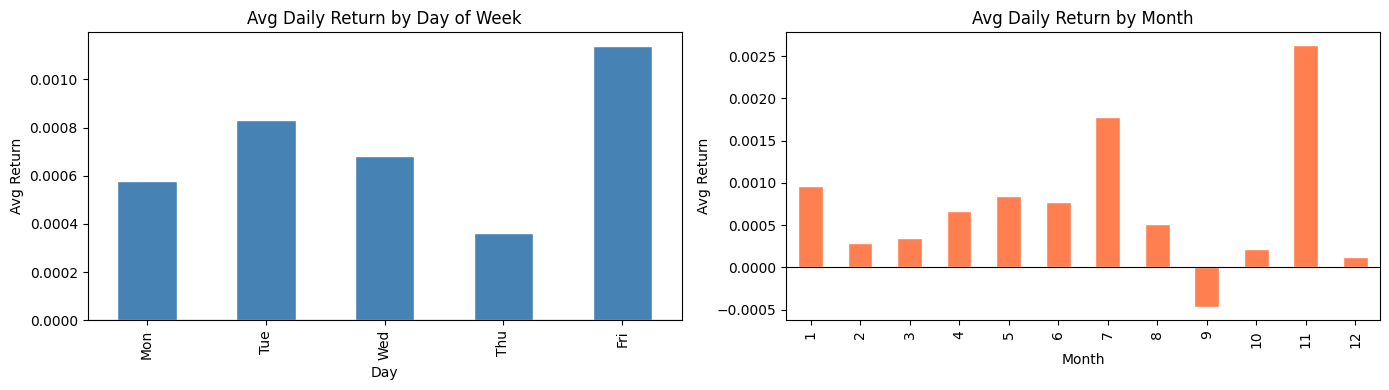

In [74]:
# 2.4 Day-of-week and month seasonality for returns
dow_ret = df.groupby('Day_of_Week')['Daily_Return'].mean().rename(
    index={0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri'})
month_ret = df.groupby('Month')['Daily_Return'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
dow_ret.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Avg Daily Return by Day of Week')
axes[0].set_xlabel('Day'); axes[0].set_ylabel('Avg Return')
axes[0].axhline(0, color='black', linewidth=0.8)

month_ret.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Avg Daily Return by Month')
axes[1].set_xlabel('Month'); axes[1].set_ylabel('Avg Return')
axes[1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()


## Step:3 Missing Values Analysis


In [75]:
# 3.1 Missing value counts & percentages (all features)
missing     = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df  = pd.DataFrame({'Missing Count': missing,
                             'Missing %': missing_pct.round(4)})
missing_df  = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(f"Columns with missing values: {len(missing_df)}")
print(missing_df)


Columns with missing values: 39
                    Missing Count  Missing %
SMA_50                      24497     2.0075
MACD_Hist                   16500     1.3522
MACD_Signal                 16500     1.3522
EMA_Cross                   12500     1.0244
EMA_26                      12500     1.0244
MACD                        12500     1.0244
Volume_Lag1                 10000     0.8195
Rolling_Std_20              10000     0.8195
Volatility_Ratio            10000     0.8195
CCI_20                       9629     0.7891
VWAP                         9607     0.7873
Price_vs_VWAP                9607     0.7873
SMA_20                       9500     0.7785
BB_Lower                     9500     0.7785
BB_Position                  9500     0.7785
Volume_MA_Ratio              9500     0.7785
BB_Mid                       9500     0.7785
BB_Width                     9500     0.7785
Price_vs_SMA20               9500     0.7785
SMA5_vs_SMA20                9500     0.7785
BB_Upper               

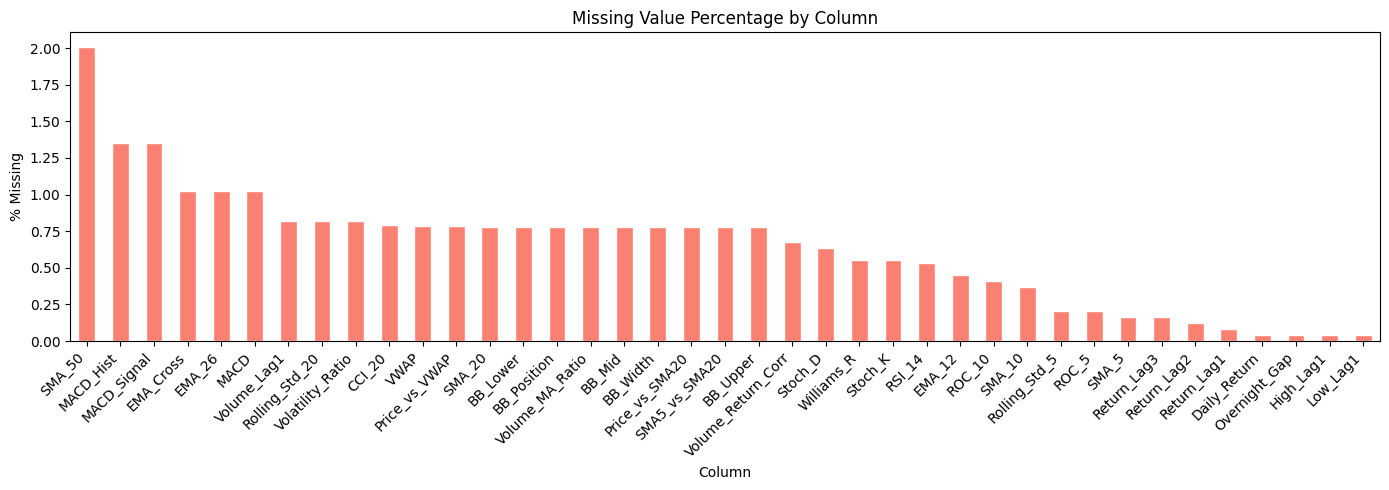

In [76]:
# 3.2 Bar chart of missing % for affected columns
fig, ax = plt.subplots(figsize=(14, 5))
if len(missing_df) > 0:
    missing_df['Missing %'].plot(kind='bar', ax=ax, color='salmon', edgecolor='white')
    ax.set_title('Missing Value Percentage by Column')
    ax.set_ylabel('% Missing')
    ax.set_xlabel('Column')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in any column.")


In [77]:
# 3.3 Why engineered features have NaNs (window warm-up)
warmup_cols = {
    'SMA_50'         : 'Window = 50 bars',
    'ADX_14'         : 'Window = 14 bars (True Range + smoothing)',
    'Rolling_Std_20' : 'Window = 20 bars',
    'BB_Width'       : 'Bollinger window = 20',
    'Return_Lag3'    : '3-bar lag',
    'Volume_Lag1'    : '1-bar lag',
}
print("Expected NaN Sources (window warm-up)")
for col, reason in warmup_cols.items():
    n = df[col].isnull().sum() if col in df.columns else 'N/A'
    print(f"  {col:<22} {str(n):>8} NaNs - {reason}")

# Incomplete stock coverage check
expected_days    = df['date'].nunique()
stock_coverage   = df.groupby('symbol')['date'].count()
incomplete_stocks = stock_coverage[stock_coverage < expected_days * 0.9]
print(f"\nStocks with <90% date coverage: {len(incomplete_stocks)}")
if len(incomplete_stocks):
    print(incomplete_stocks.sort_values().head(10))


Expected NaN Sources (window warm-up)
  SMA_50                    24497 NaNs - Window = 50 bars
  ADX_14                        0 NaNs - Window = 14 bars (True Range + smoothing)
  Rolling_Std_20            10000 NaNs - Window = 20 bars
  BB_Width                   9500 NaNs - Bollinger window = 20
  Return_Lag3                2000 NaNs - 3-bar lag
  Volume_Lag1               10000 NaNs - 1-bar lag

Stocks with <90% date coverage: 30
symbol
Q         46
SNDK     222
GEV      443
SOLV     444
VLTO     563
KVUE     668
GEHC     763
CEG      992
HOOD    1112
APP     1185
Name: date, dtype: int64


## Step:4 Outlier Detection

In [78]:
# 4.1 IQR outlier count for OHLCV
def count_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()

print("OHLCV Outlier Counts (IQR method)")
for col in ['open', 'high', 'low', 'close', 'volume']:
    n = count_outliers_iqr(df[col])
    print(f"  {col:<8}: {n:>7,}  ({n/len(df)*100:.2f}%)")

OHLCV Outlier Counts (IQR method)
  open    :  90,989  (7.46%)
  high    :  91,150  (7.47%)
  low     :  90,740  (7.44%)
  close   :  90,988  (7.46%)
  volume  : 127,161  (10.42%)


In [79]:
# 4.2 IQR outlier count for engineered features
eng_cols = ['Daily_Return', 'Overnight_Gap', 'HL_Range', 'CO_Spread',
            'RSI_14', 'ATR_14', 'BB_Width', 'Volume_MA_Ratio',
            'CCI_20', 'ROC_5', 'Volatility_Ratio']

print("Engineered Feature Outlier Counts (IQR method)")
for col in eng_cols:
    if col in df.columns:
        n = count_outliers_iqr(df[col].dropna())
        print(f"  {col:<22}: {n:>7,}  ({n/df[col].dropna().shape[0]*100:.2f}%)")

Engineered Feature Outlier Counts (IQR method)
  Daily_Return          :  77,935  (6.39%)
  Overnight_Gap         : 106,603  (8.74%)
  HL_Range              :  70,609  (5.79%)
  CO_Spread             :  67,330  (5.52%)
  RSI_14                :   2,806  (0.23%)
  ATR_14                : 101,340  (8.30%)
  BB_Width              :  69,057  (5.70%)
  Volume_MA_Ratio       :  61,994  (5.12%)
  CCI_20                :   3,100  (0.26%)
  ROC_5                 :  69,533  (5.71%)
  Volatility_Ratio      :   2,395  (0.20%)


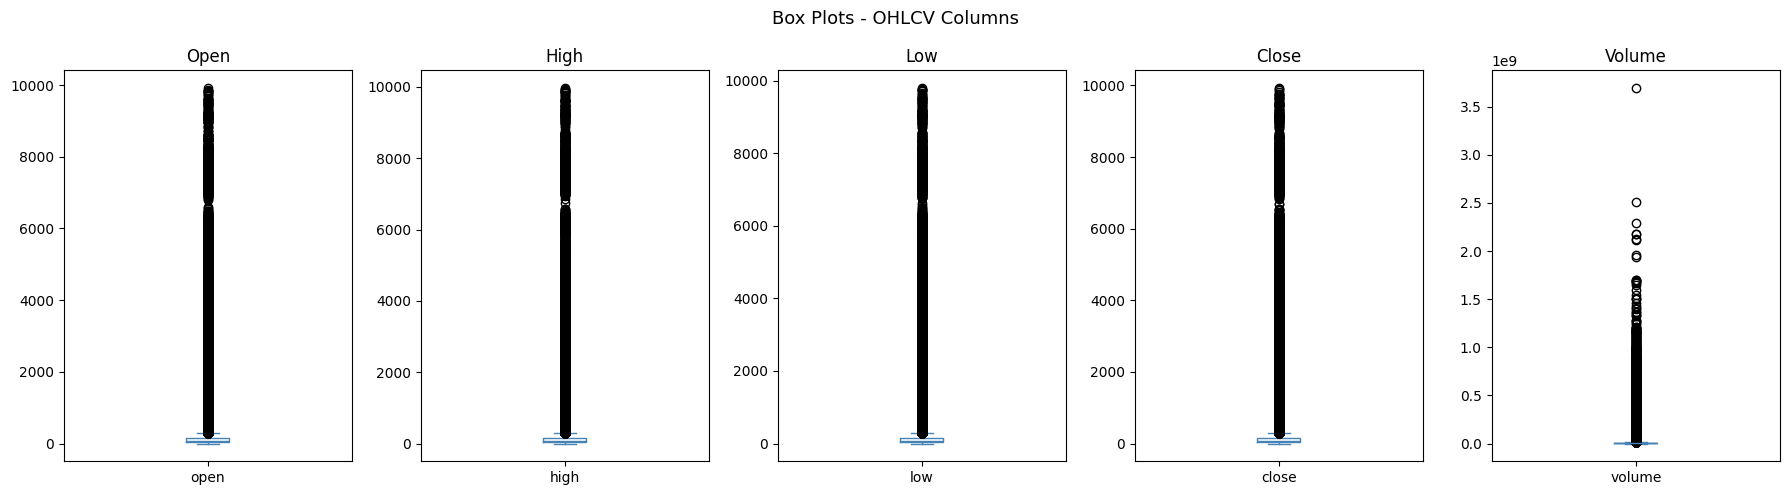

In [80]:
# 4.3 Box plots - OHLCV columns
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for ax, col in zip(axes, ['open', 'high', 'low', 'close', 'volume']):
    df[col].plot(kind='box', ax=ax, color='steelblue')
    ax.set_title(col.capitalize())
    ax.set_xlabel('')
plt.suptitle('Box Plots - OHLCV Columns', fontsize=13)
plt.tight_layout()
plt.show()

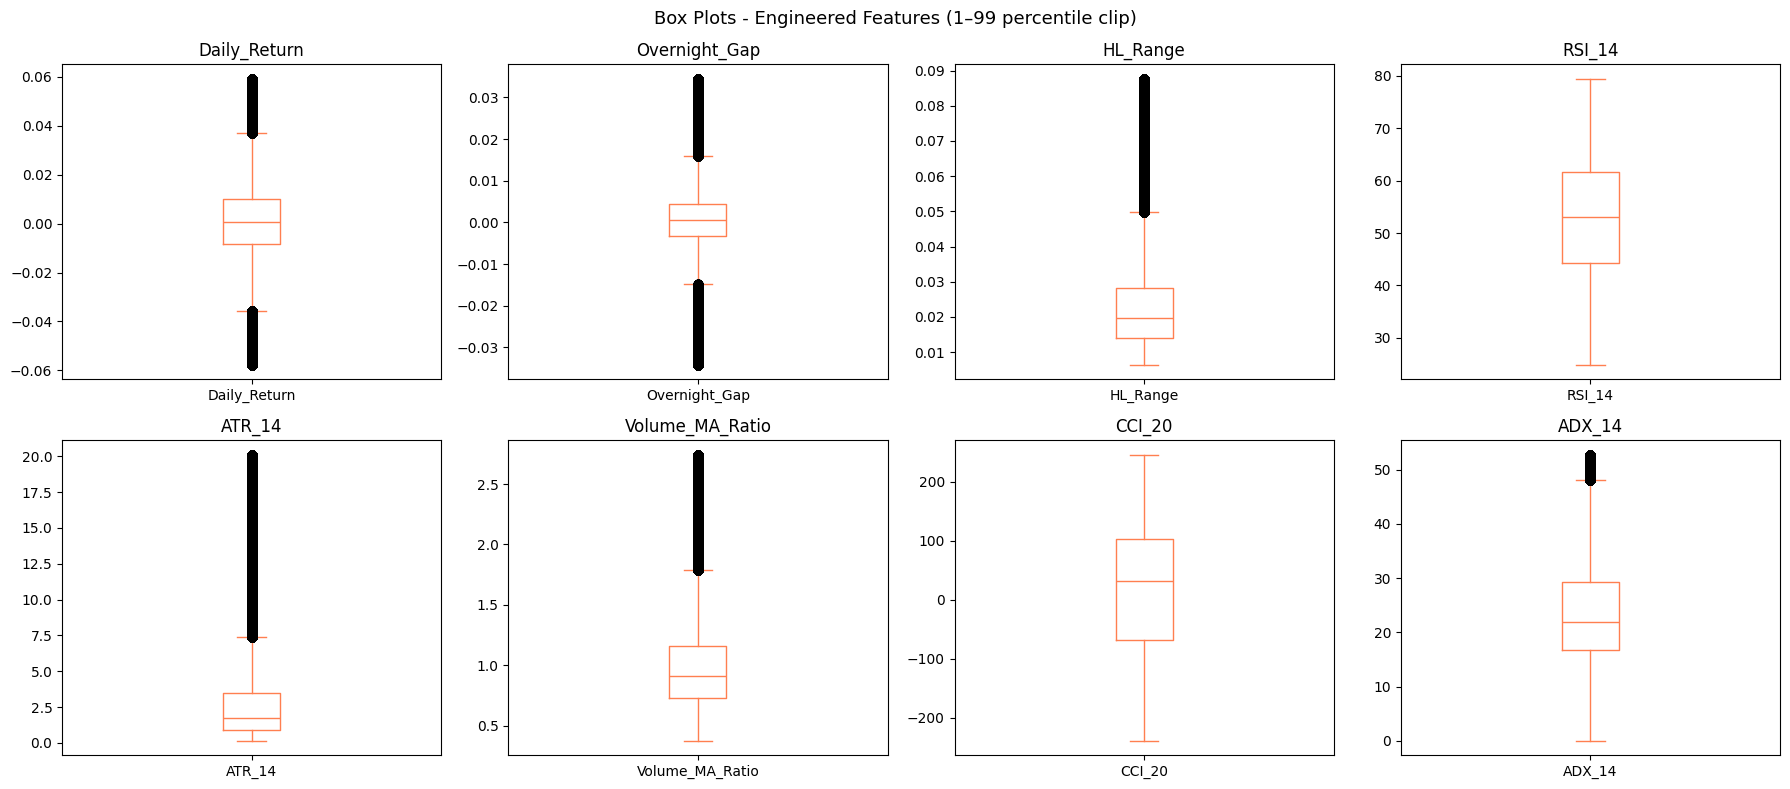

In [81]:
# 4.4 Box plots - key engineered features
eng_plot_cols = ['Daily_Return', 'Overnight_Gap', 'HL_Range',
                 'RSI_14', 'ATR_14', 'Volume_MA_Ratio', 'CCI_20', 'ADX_14']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for ax, col in zip(axes, eng_plot_cols):
    if col in df.columns:
        df[col].dropna().clip(
            df[col].quantile(0.01), df[col].quantile(0.99)
        ).plot(kind='box', ax=ax, color='coral')
        ax.set_title(col)
plt.suptitle('Box Plots - Engineered Features (1–99 percentile clip)', fontsize=13)
plt.tight_layout()
plt.show()

In [82]:
# 4.5 Data integrity checks
invalid_hl = (df['high'] < df['low']).sum()
invalid_hc = (df['high'] < df['close']).sum()
invalid_lo = (df['low']  > df['open']).sum()
neg_vol    = (df['volume'] <= 0).sum()
print(f"Rows where high < low   : {invalid_hl}")
print(f"Rows where high < close : {invalid_hc}")
print(f"Rows where low > open   : {invalid_lo}")
print(f"Rows where volume <= 0  : {neg_vol}")

Rows where high < low   : 0
Rows where high < close : 109
Rows where low > open   : 1
Rows where volume <= 0  : 1904


## Step:5 Distribution Analysis

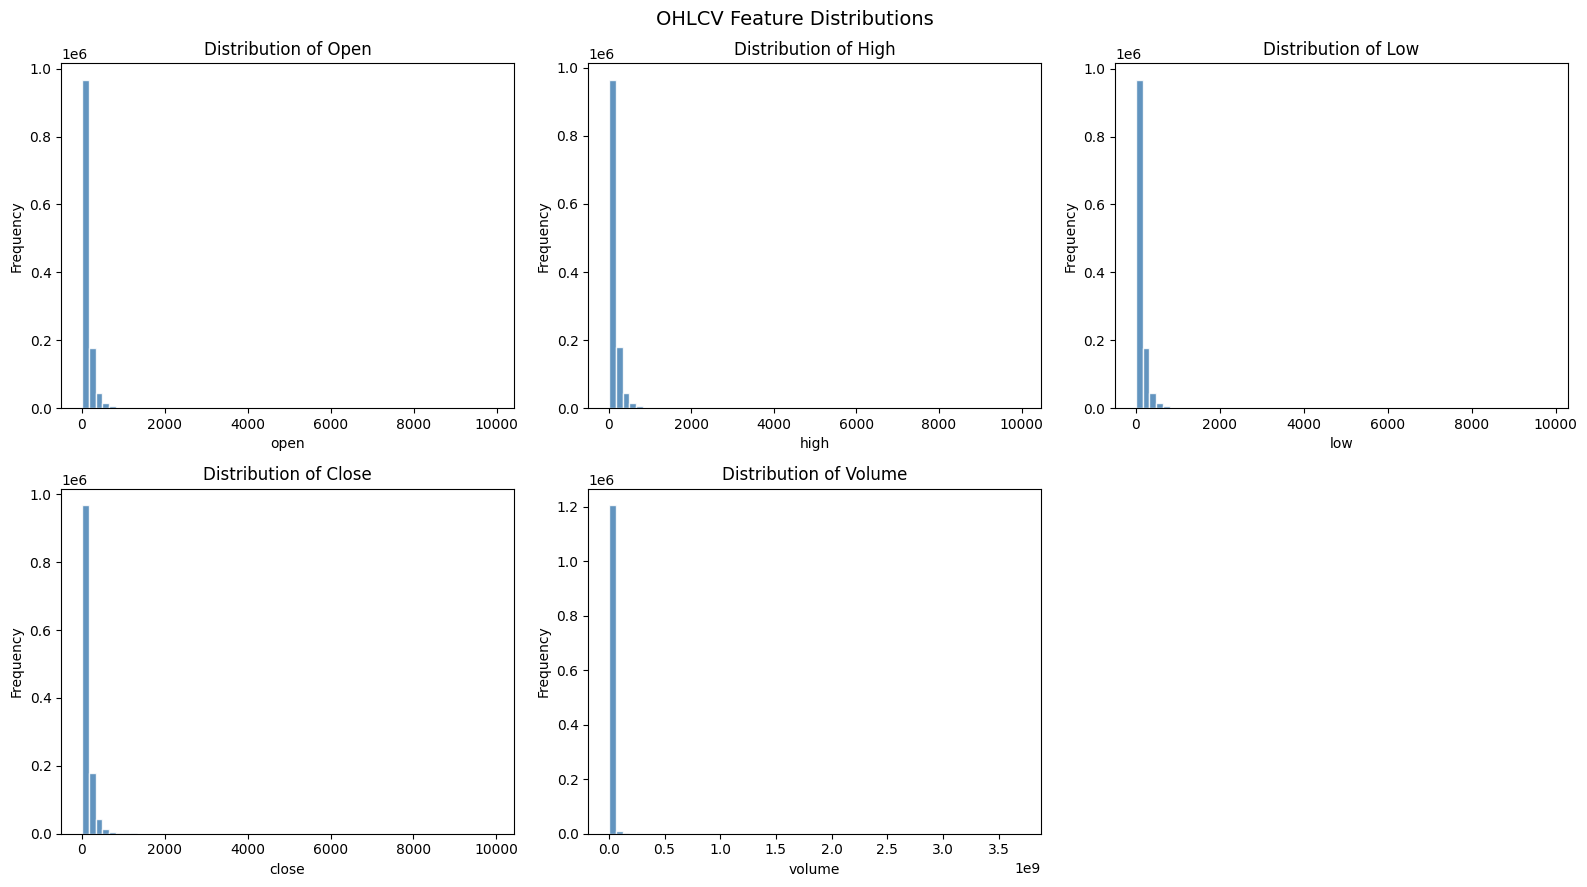

In [83]:
# 5.1 OHLCV histograms
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(['open', 'high', 'low', 'close', 'volume']):
    axes[i].hist(df[col].dropna(), bins=60, color='steelblue',
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col.capitalize()}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
axes[-1].set_visible(False)
plt.suptitle('OHLCV Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

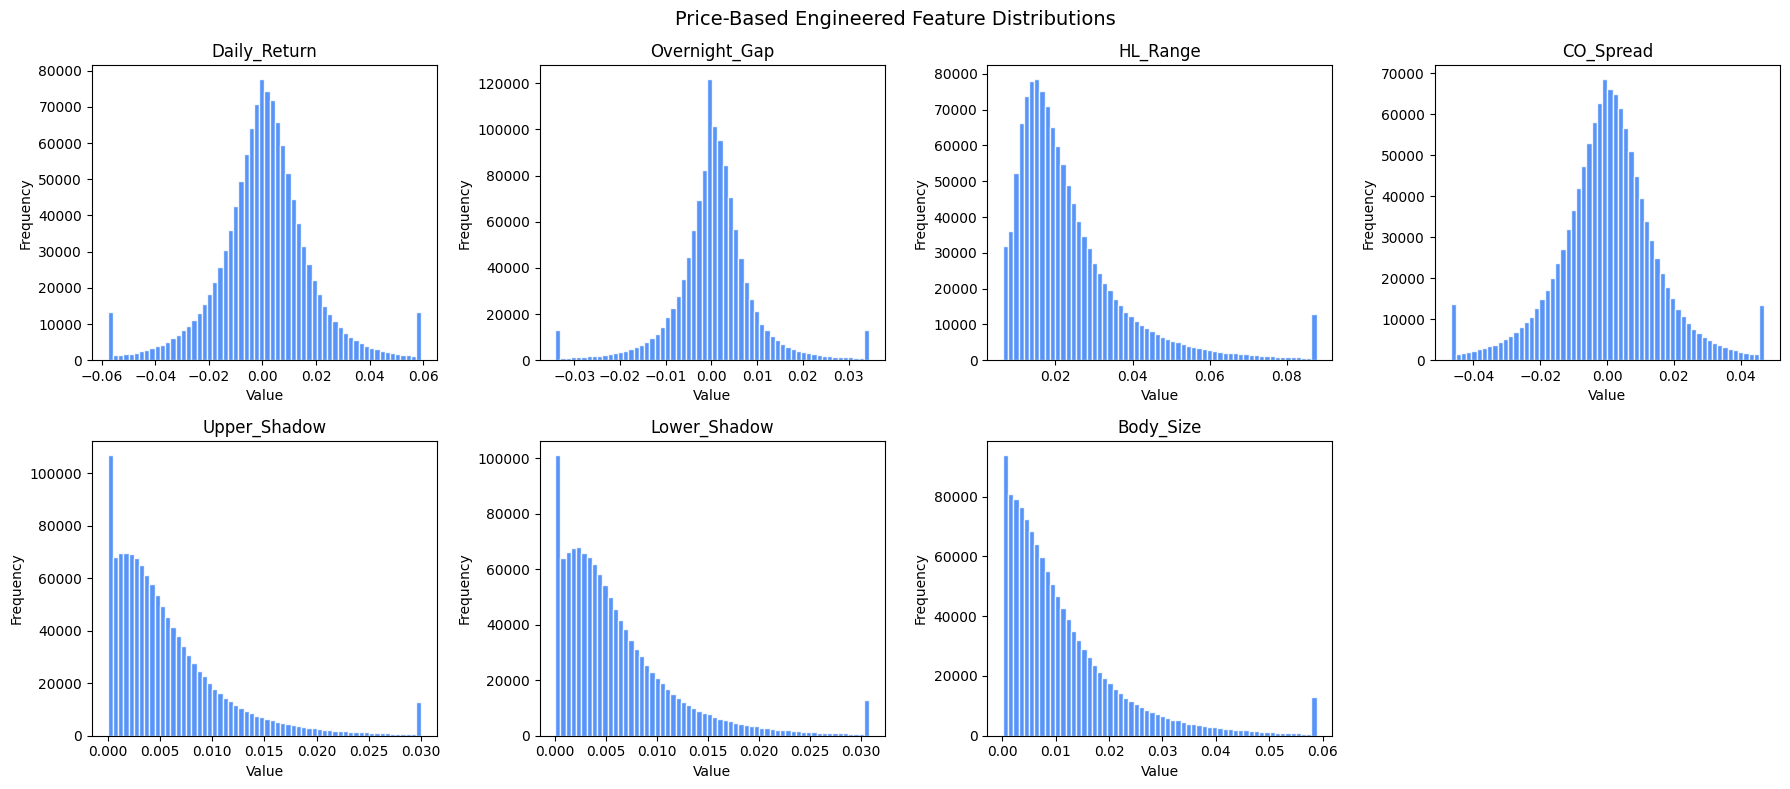

In [84]:
# 5.2 Engineered price-based feature distributions
price_feats = ['Daily_Return', 'Overnight_Gap', 'HL_Range',
               'CO_Spread', 'Upper_Shadow', 'Lower_Shadow', 'Body_Size']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(price_feats):
    if col in df.columns:
        data = df[col].dropna().clip(df[col].quantile(0.01), df[col].quantile(0.99))
        axes[i].hist(data, bins=60, color='#3b82f6', edgecolor='white', alpha=0.85)
        axes[i].set_title(col)
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')
axes[-1].set_visible(False)
plt.suptitle('Price-Based Engineered Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

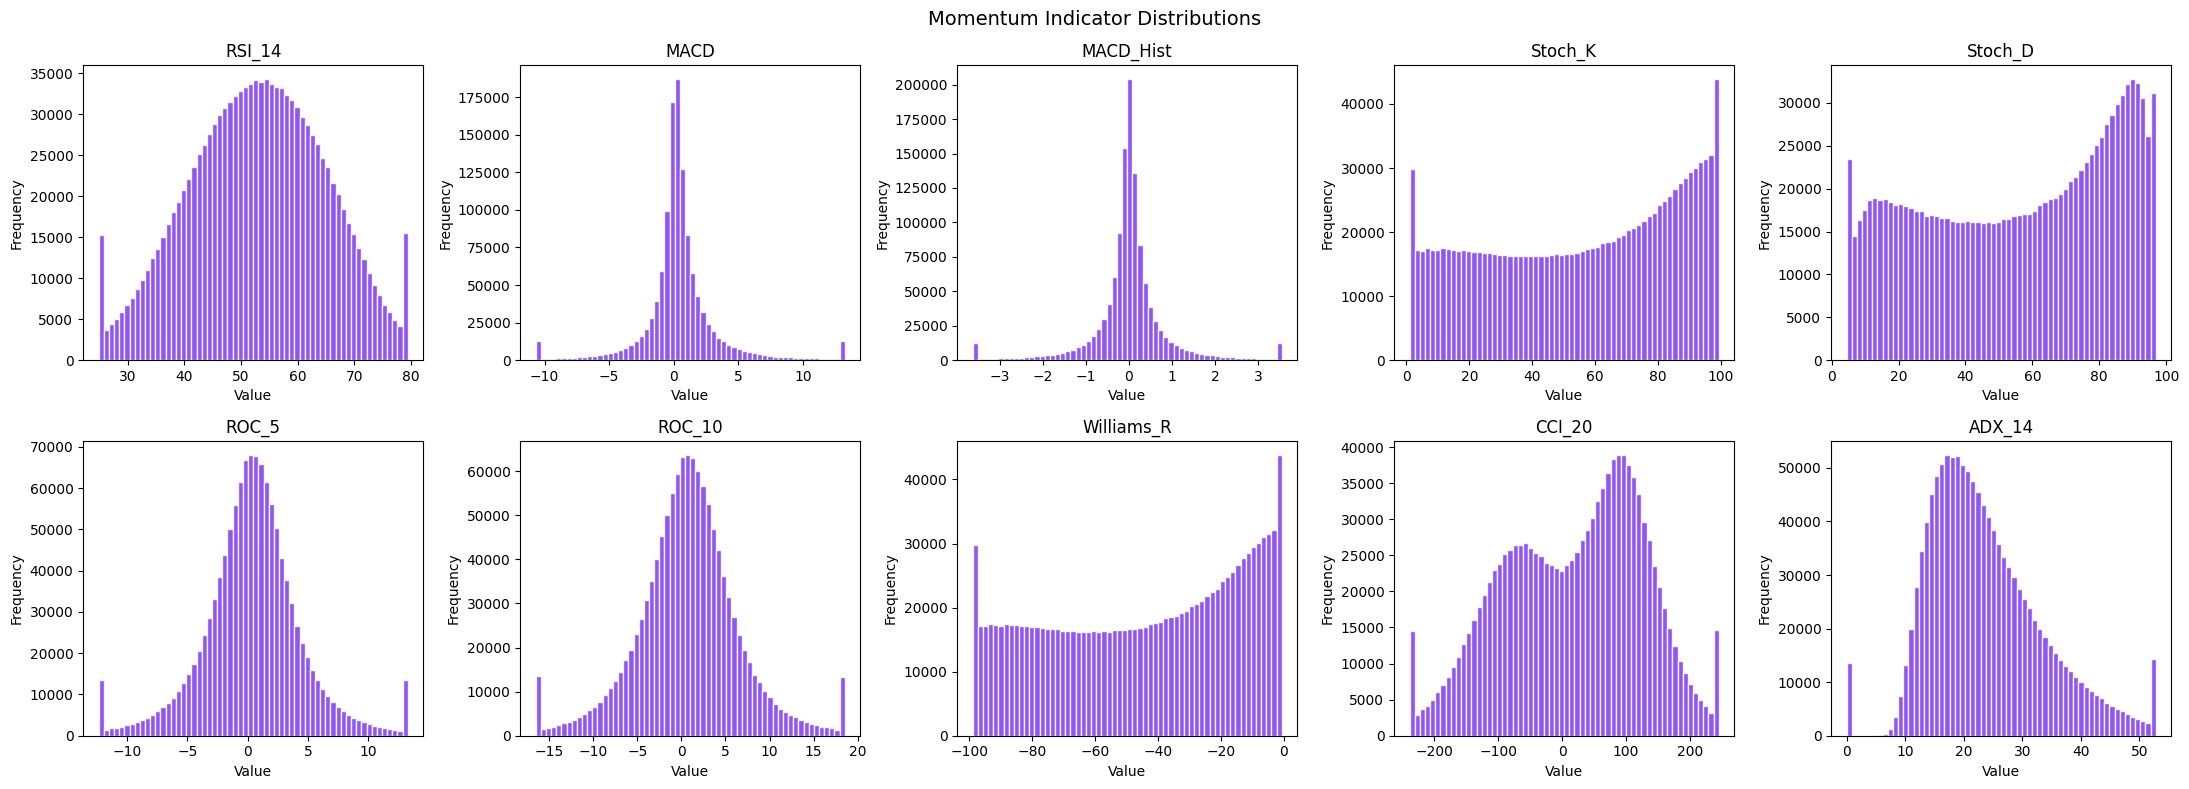

In [85]:
# 5.3 Momentum indicator distributions
mom_feats = ['RSI_14', 'MACD', 'MACD_Hist', 'Stoch_K', 'Stoch_D',
             'ROC_5', 'ROC_10', 'Williams_R', 'CCI_20', 'ADX_14']
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
for i, col in enumerate(mom_feats):
    if col in df.columns:
        data = df[col].dropna().clip(df[col].quantile(0.01), df[col].quantile(0.99))
        axes[i].hist(data, bins=60, color='#7c3aed', edgecolor='white', alpha=0.85)
        axes[i].set_title(col)
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')
plt.suptitle('Momentum Indicator Distributions', fontsize=14)
plt.tight_layout()
plt.show()

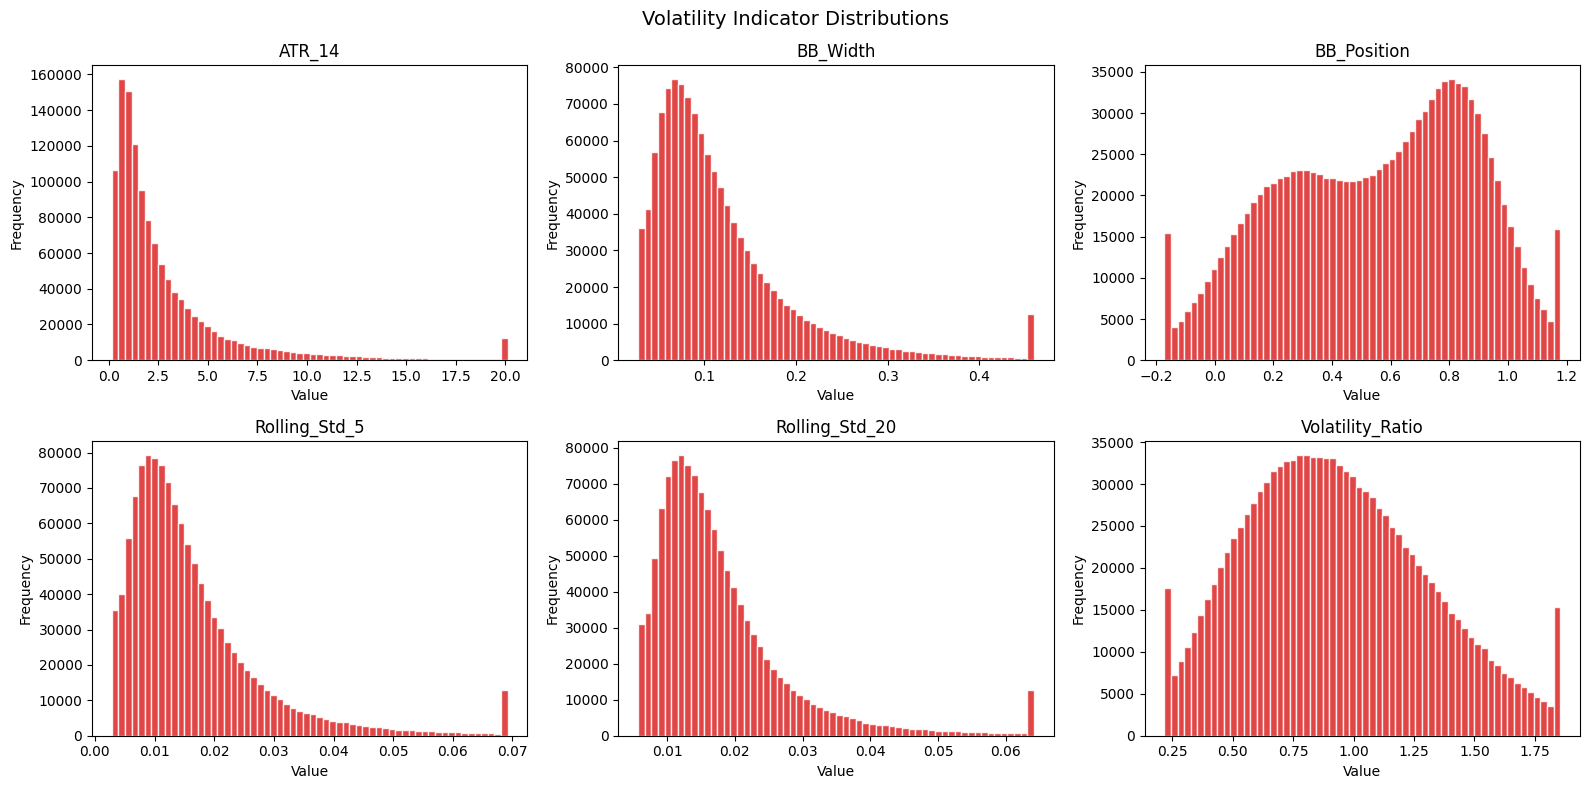

In [86]:
# 5.4 Volatility indicator distributions
vol_feats = ['ATR_14', 'BB_Width', 'BB_Position',
             'Rolling_Std_5', 'Rolling_Std_20', 'Volatility_Ratio']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(vol_feats):
    if col in df.columns:
        data = df[col].dropna().clip(df[col].quantile(0.01), df[col].quantile(0.99))
        axes[i].hist(data, bins=60, color='#dc2626', edgecolor='white', alpha=0.85)
        axes[i].set_title(col)
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')
plt.suptitle('Volatility Indicator Distributions', fontsize=14)
plt.tight_layout()
plt.show()

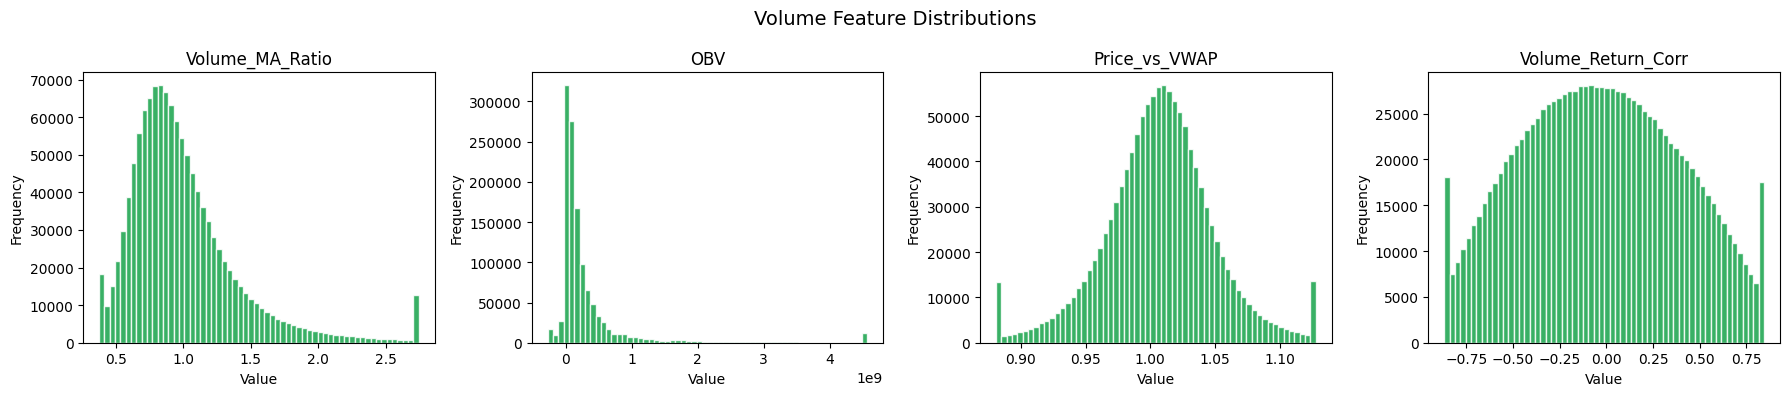

In [87]:
# 5.5 Volume-based feature distributions
volume_feats = ['Volume_MA_Ratio', 'OBV', 'Price_vs_VWAP', 'Volume_Return_Corr']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, col in enumerate(volume_feats):
    if col in df.columns:
        data = df[col].dropna().clip(df[col].quantile(0.01), df[col].quantile(0.99))
        axes[i].hist(data, bins=60, color='#16a34a', edgecolor='white', alpha=0.85)
        axes[i].set_title(col)
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')
plt.suptitle('Volume Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

## Step:6 Correlation & Relationship Analysis

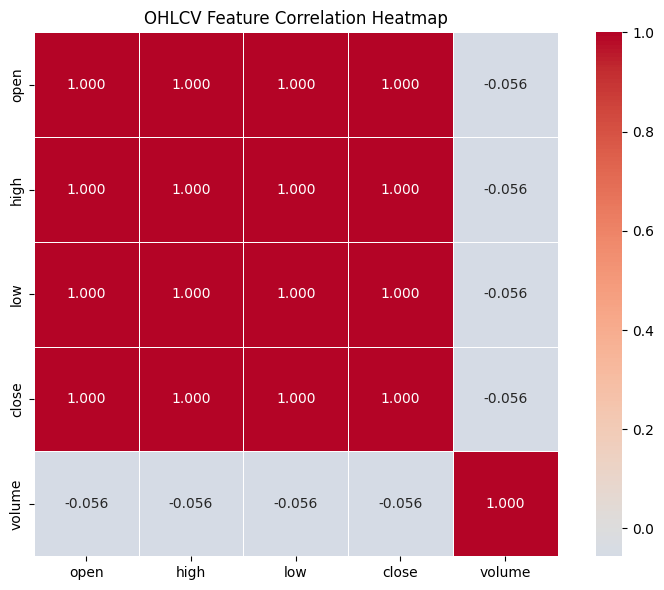

Interpretation: Open/High/Low/Close are strongly correlated (multicollinearity risk).
Volume has weaker correlation - may serve as an independent signal.


In [88]:
# 6.1 OHLCV correlation heatmap
corr = df[['open', 'high', 'low', 'close', 'volume']].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('OHLCV Feature Correlation Heatmap')
plt.tight_layout()
plt.show()
print("Interpretation: Open/High/Low/Close are strongly correlated (multicollinearity risk).")
print("Volume has weaker correlation - may serve as an independent signal.")

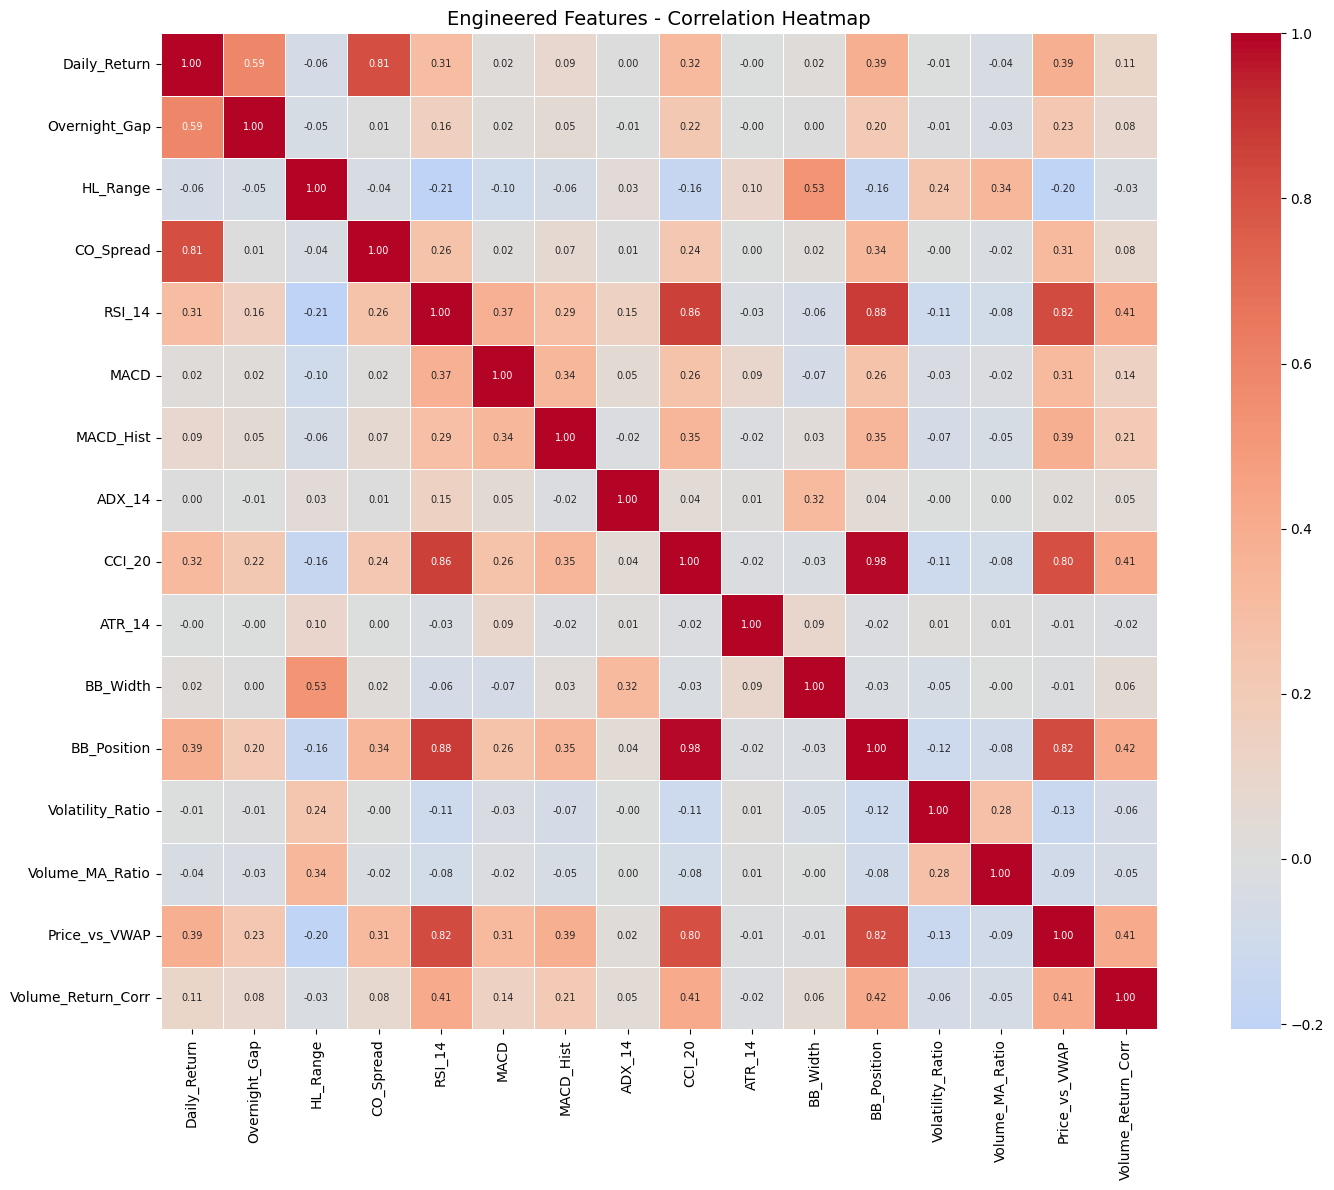

In [89]:
# 6.2 Engineered features correlation heatmap
eng_corr_cols = ['Daily_Return', 'Overnight_Gap', 'HL_Range', 'CO_Spread',
                 'RSI_14', 'MACD', 'MACD_Hist', 'ADX_14', 'CCI_20',
                 'ATR_14', 'BB_Width', 'BB_Position', 'Volatility_Ratio',
                 'Volume_MA_Ratio', 'Price_vs_VWAP', 'Volume_Return_Corr']
eng_corr_cols = [c for c in eng_corr_cols if c in df.columns]

corr_eng = df[eng_corr_cols].corr()
fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr_eng, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.4, annot_kws={'size': 7}, ax=ax)
ax.set_title('Engineered Features - Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

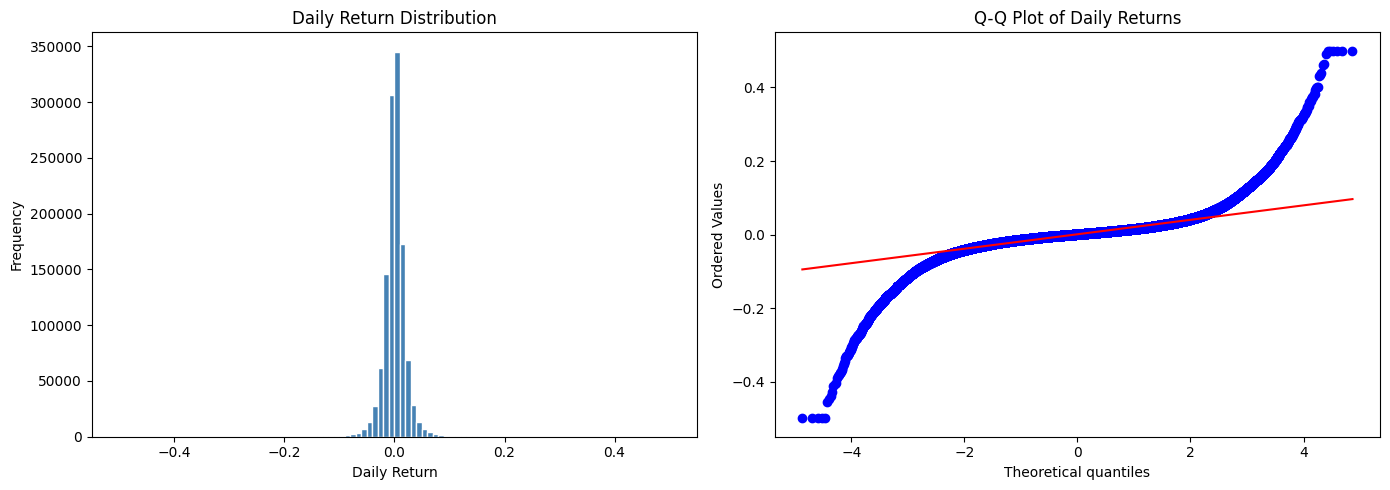

Skewness : 0.1919
Kurtosis : 25.6717
Heavy tails (excess kurtosis > 0) are typical for equity returns.


In [90]:
# 6.3 Daily return distribution + Q-Q plot
# Use the already-computed Daily_Return from Step 1 (avoids recomputing)
ret = df['Daily_Return'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ret.clip(-0.5, 0.5).plot(kind='hist', bins=100, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Daily Return Distribution')
axes[0].set_xlabel('Daily Return')

stats.probplot(ret.clip(-0.5, 0.5), plot=axes[1])
axes[1].set_title('Q-Q Plot of Daily Returns')
plt.tight_layout()
plt.show()

print(f"Skewness : {ret.skew():.4f}")
print(f"Kurtosis : {ret.kurtosis():.4f}")
print("Heavy tails (excess kurtosis > 0) are typical for equity returns.")

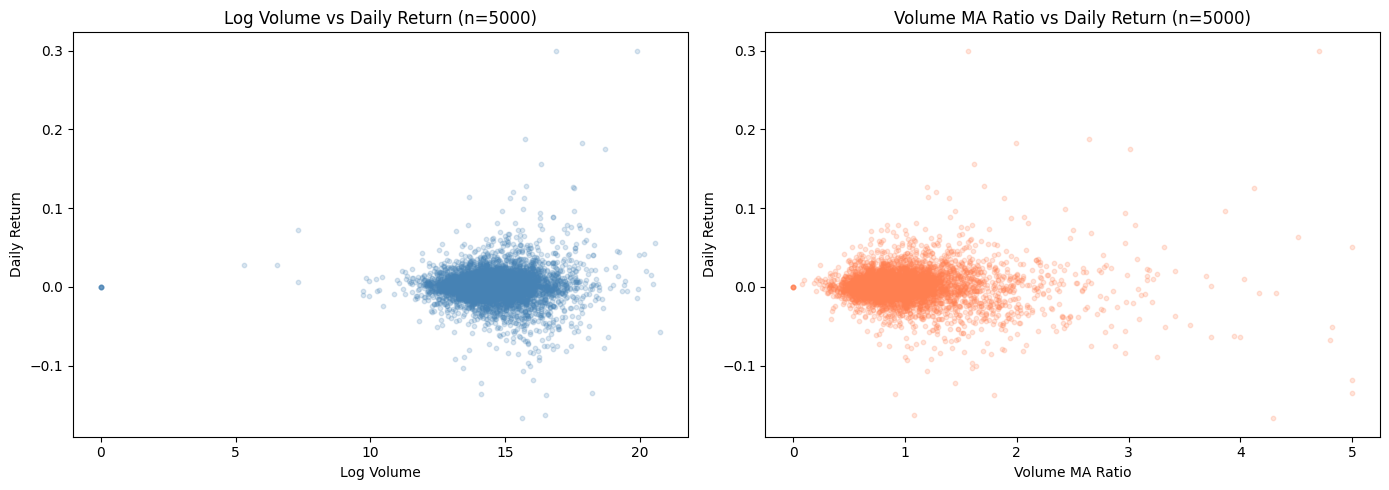

In [91]:
# 6.4 Volume vs Daily Return scatter
sample = df[['volume', 'Daily_Return', 'Volume_MA_Ratio']].dropna().sample(5000, random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(np.log1p(sample['volume']), sample['Daily_Return'].clip(-0.3, 0.3),
                alpha=0.2, s=10, color='steelblue')
axes[0].set_xlabel('Log Volume')
axes[0].set_ylabel('Daily Return')
axes[0].set_title('Log Volume vs Daily Return (n=5000)')

axes[1].scatter(sample['Volume_MA_Ratio'].clip(0, 5), sample['Daily_Return'].clip(-0.3, 0.3),
                alpha=0.2, s=10, color='coral')
axes[1].set_xlabel('Volume MA Ratio')
axes[1].set_ylabel('Daily Return')
axes[1].set_title('Volume MA Ratio vs Daily Return (n=5000)')

plt.tight_layout()
plt.show()

Top 20 features by |correlation| with Daily_Return:
CO_Spread             0.8116
Overnight_Gap         0.5880
ROC_5                 0.4269
BB_Position           0.3921
Stoch_K               0.3876
Williams_R            0.3876
Price_vs_VWAP         0.3852
Price_vs_SMA20        0.3718
CCI_20                0.3198
ROC_10                0.3087
RSI_14                0.3057
Stoch_D               0.1310
Volume_Return_Corr    0.1093
MACD_Hist             0.0850
HL_Range             -0.0632
SMA5_vs_SMA20         0.0609
Lower_Shadow         -0.0524
Body_Size            -0.0417
Volume_MA_Ratio      -0.0384
Return_Lag1          -0.0332
Name: Daily_Return, dtype: float64


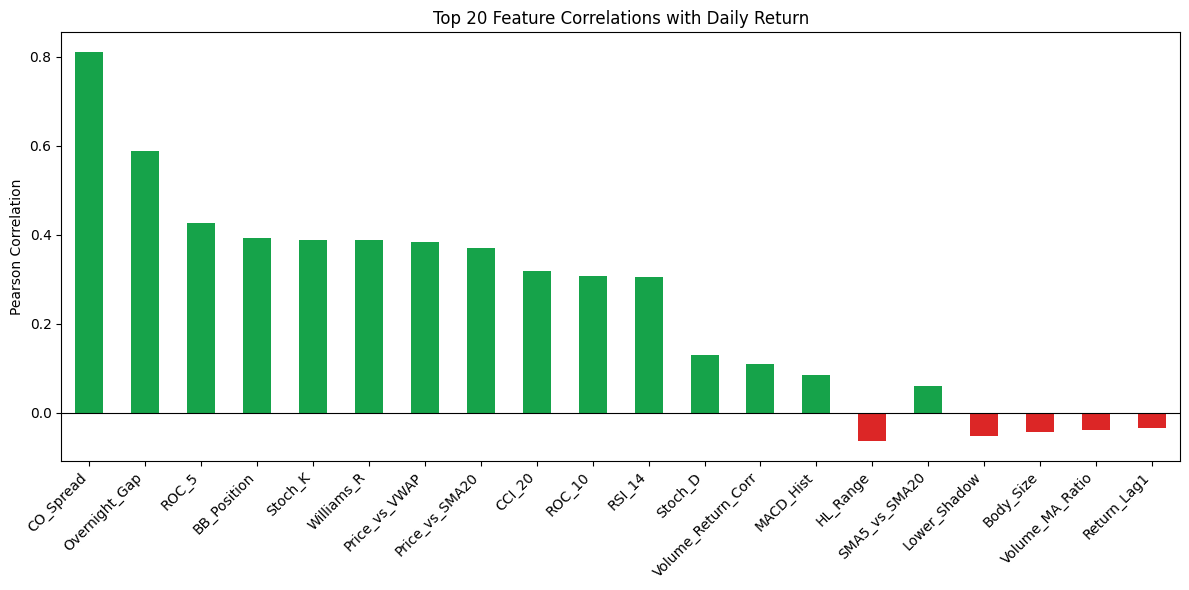

In [92]:
# 6.5 Feature correlations with Daily_Return (signal strength)
target_col = 'Daily_Return'
candidate_cols = [c for c in df.select_dtypes(include='number').columns
                  if c not in ['open','high','low','close','volume',
                                'Day_of_Week','Month','Is_Month_End',
                                'Volume_Spike','Consecutive_Up', target_col]]

corr_with_return = (df[candidate_cols + [target_col]]
                    .corr()[target_col]
                    .drop(target_col)
                    .sort_values(key=abs, ascending=False))

print("Top 20 features by |correlation| with Daily_Return:")
print(corr_with_return.head(20).round(4))

fig, ax = plt.subplots(figsize=(12, 6))
corr_with_return.head(20).plot(kind='bar', ax=ax,
    color=['#16a34a' if v > 0 else '#dc2626' for v in corr_with_return.head(20)])
ax.set_title('Top 20 Feature Correlations with Daily Return')
ax.set_ylabel('Pearson Correlation')
ax.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step:7 Time Series Trend Analysis

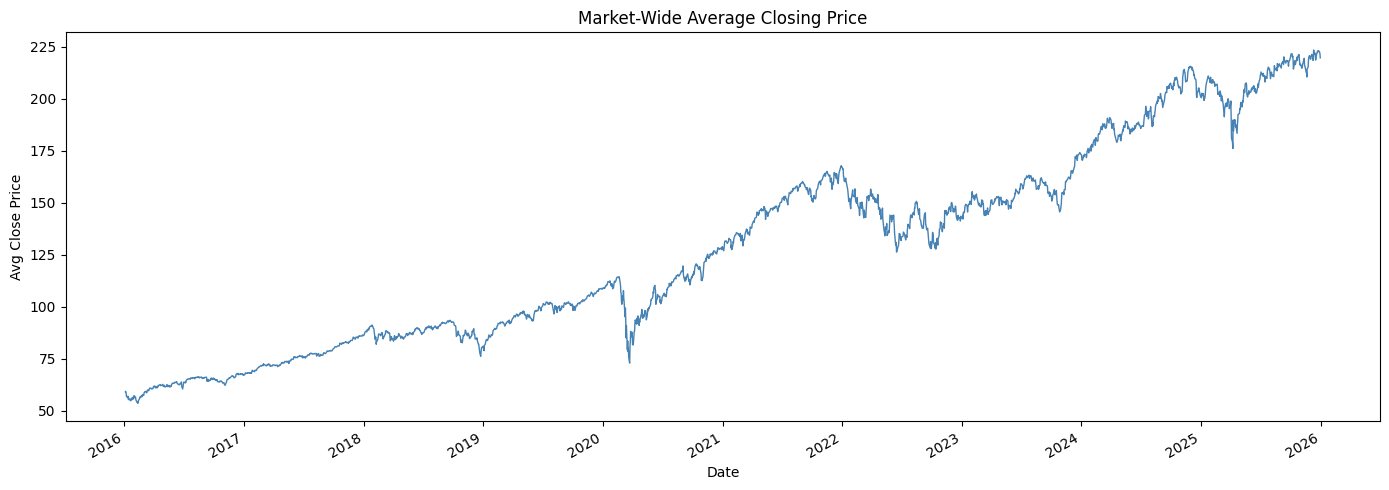

In [93]:
# 7.1 Market-wide average close price over time
daily_avg = df.groupby('date')['close'].mean()
fig, ax = plt.subplots(figsize=(14, 5))
daily_avg.plot(ax=ax, color='steelblue', linewidth=1)
ax.set_title('Market-Wide Average Closing Price')
ax.set_xlabel('Date'); ax.set_ylabel('Avg Close Price')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

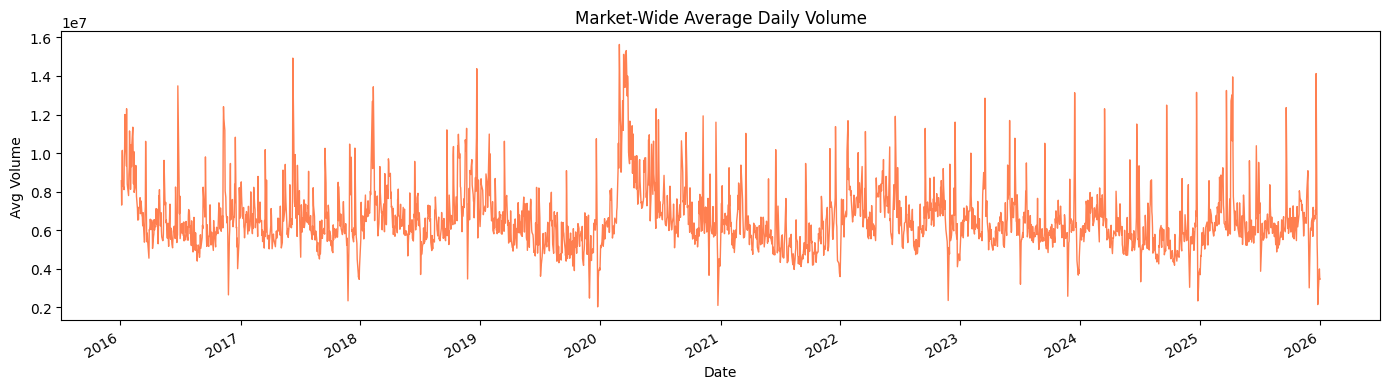

In [94]:
# 7.2 Average daily volume over time
daily_vol = df.groupby('date')['volume'].mean()
fig, ax = plt.subplots(figsize=(14, 4))
daily_vol.plot(ax=ax, color='coral', linewidth=1)
ax.set_title('Market-Wide Average Daily Volume')
ax.set_xlabel('Date'); ax.set_ylabel('Avg Volume')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

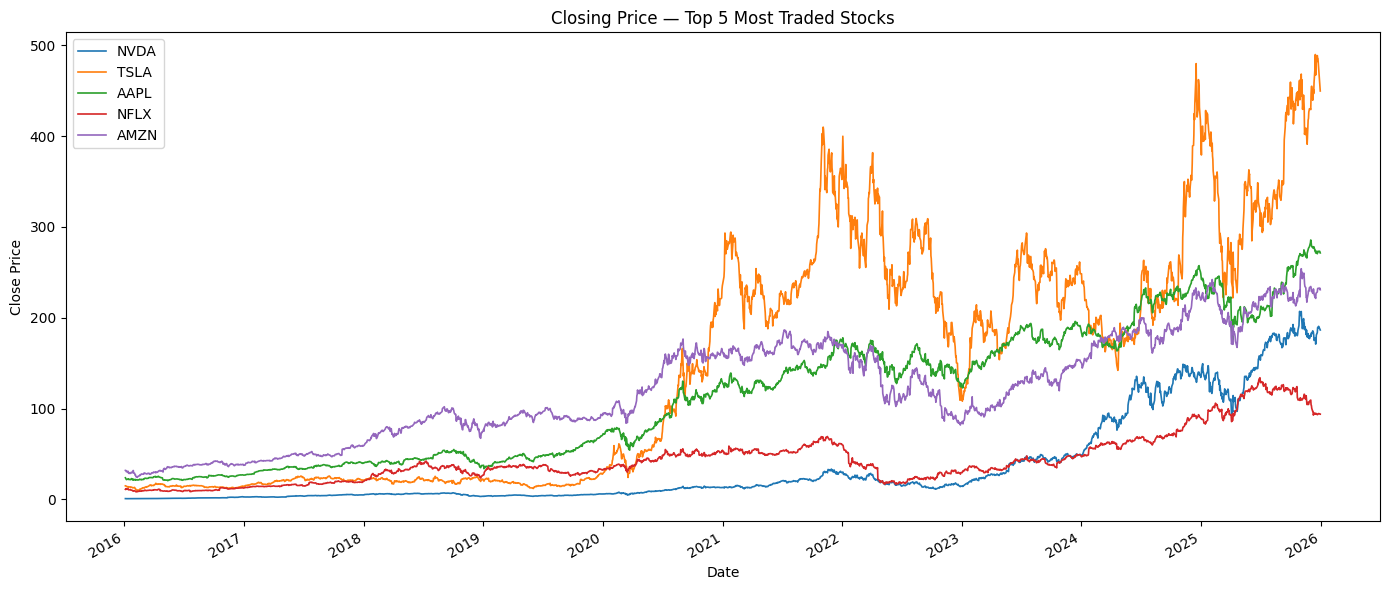

In [95]:
# 7.3 Closing price for top-5 most-traded stocks
top5 = symbol_stats.sort_values('avg_volume', ascending=False).head(5).index.tolist()
fig, ax = plt.subplots(figsize=(14, 6))
for sym in top5:
    df[df['symbol'] == sym].set_index('date')['close'].plot(ax=ax, label=sym, linewidth=1.2)
ax.set_title('Closing Price — Top 5 Most Traded Stocks')
ax.set_xlabel('Date'); ax.set_ylabel('Close Price')
ax.legend()
plt.tight_layout()
plt.show()

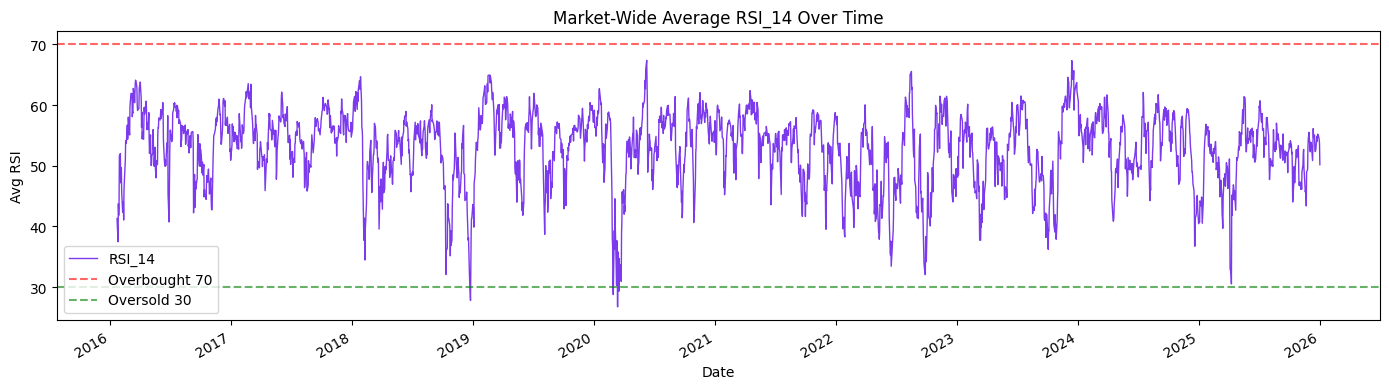

In [96]:
# 7.4 Market-wide RSI_14 trend (avg across all stocks)
daily_rsi = df.groupby('date')['RSI_14'].mean()
fig, ax = plt.subplots(figsize=(14, 4))
daily_rsi.plot(ax=ax, color='#7c3aed', linewidth=1)
ax.axhline(70, color='red',   linestyle='--', alpha=0.6, label='Overbought 70')
ax.axhline(30, color='green', linestyle='--', alpha=0.6, label='Oversold 30')
ax.set_title('Market-Wide Average RSI_14 Over Time')
ax.set_xlabel('Date'); ax.set_ylabel('Avg RSI')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

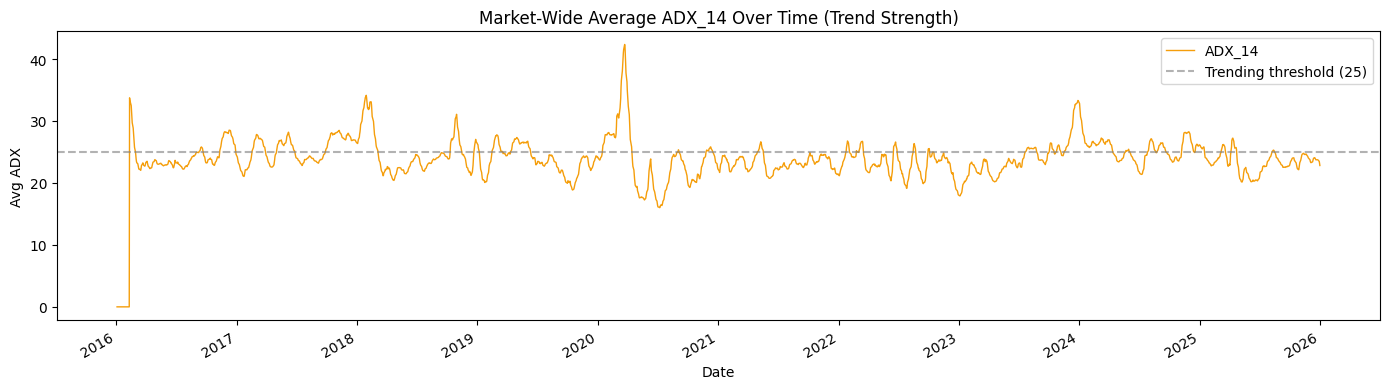

In [97]:
# 7.5 Market-wide ADX_14 trend (trend strength over time)
daily_adx = df.groupby('date')['ADX_14'].mean()
fig, ax = plt.subplots(figsize=(14, 4))
daily_adx.plot(ax=ax, color='#f59e0b', linewidth=1)
ax.axhline(25, color='gray', linestyle='--', alpha=0.6, label='Trending threshold (25)')
ax.set_title('Market-Wide Average ADX_14 Over Time (Trend Strength)')
ax.set_xlabel('Date'); ax.set_ylabel('Avg ADX')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()


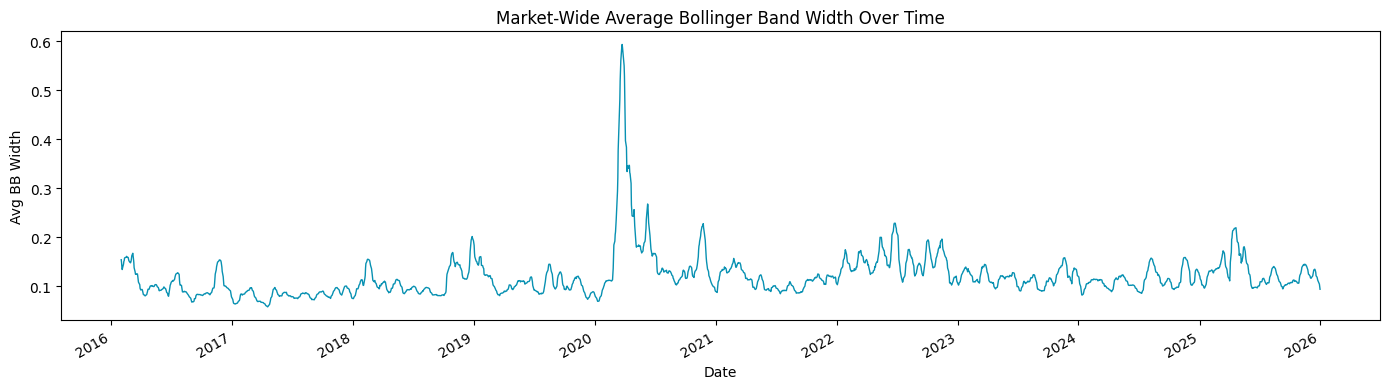

Note: Spikes in BB Width indicate market-wide volatility expansions (e.g. COVID-19 2020).


In [98]:
# 7.6 Market-wide Bollinger Band Width (expansion/contraction cycles)
daily_bbw = df.groupby('date')['BB_Width'].mean()
fig, ax = plt.subplots(figsize=(14, 4))
daily_bbw.plot(ax=ax, color='#0891b2', linewidth=1)
ax.set_title('Market-Wide Average Bollinger Band Width Over Time')
ax.set_xlabel('Date'); ax.set_ylabel('Avg BB Width')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()
print("Note: Spikes in BB Width indicate market-wide volatility expansions (e.g. COVID-19 2020).")

## Step:8 Market Volatility Analysis

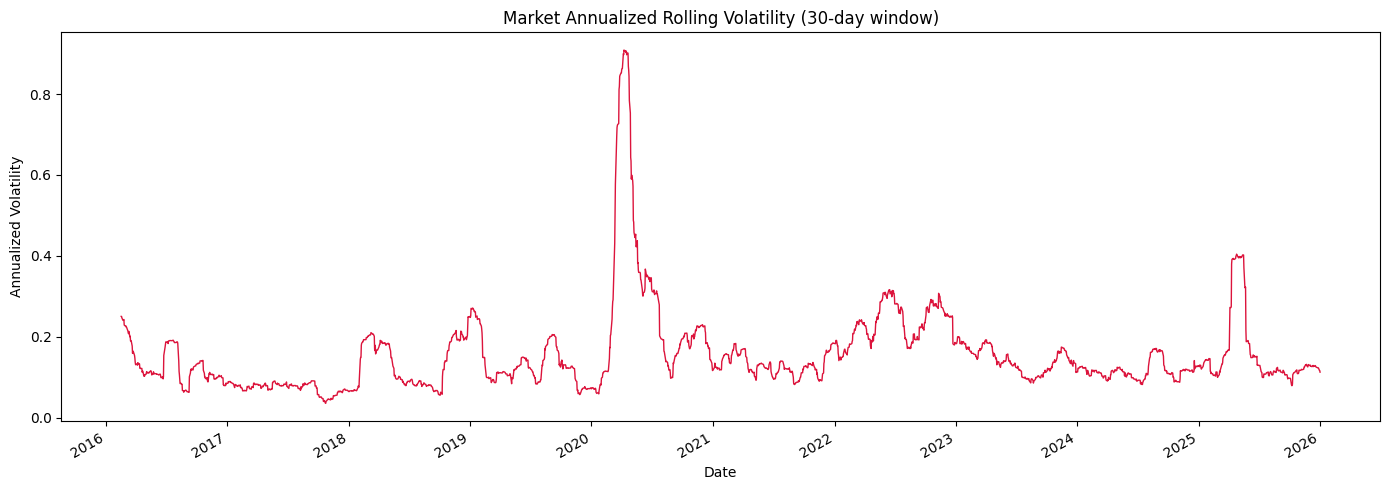

The 2020 spike corresponds to the COVID-19 market shock.


In [99]:
# 8.1 Market annualised rolling volatility (30-day)
market_returns = df.groupby('date')['Daily_Return'].mean()
rolling_vol_30 = market_returns.rolling(30).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(14, 5))
rolling_vol_30.plot(ax=ax, color='crimson', linewidth=1)
ax.set_title('Market Annualized Rolling Volatility (30-day window)')
ax.set_xlabel('Date'); ax.set_ylabel('Annualized Volatility')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()
print("The 2020 spike corresponds to the COVID-19 market shock.")

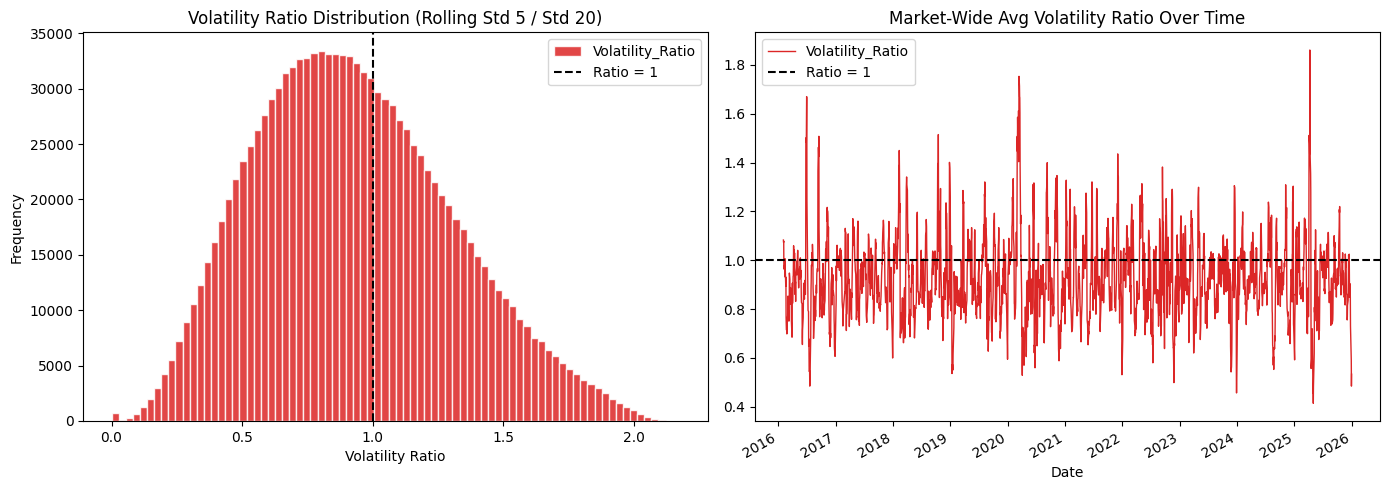

In [100]:
# 8.2 Volatility Ratio distribution (short vs long-term vol)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Volatility_Ratio'].clip(0, 5).plot(kind='hist', bins=80, ax=axes[0],
    color='#dc2626', edgecolor='white', alpha=0.85)
axes[0].set_title('Volatility Ratio Distribution (Rolling Std 5 / Std 20)')
axes[0].axvline(1.0, color='black', linestyle='--', label='Ratio = 1')
axes[0].set_xlabel('Volatility Ratio'); axes[0].legend()

daily_vr = df.groupby('date')['Volatility_Ratio'].mean()
daily_vr.plot(ax=axes[1], color='#dc2626', linewidth=1)
axes[1].axhline(1.0, color='black', linestyle='--', label='Ratio = 1')
axes[1].set_title('Market-Wide Avg Volatility Ratio Over Time')
axes[1].set_xlabel('Date'); axes[1].legend()
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

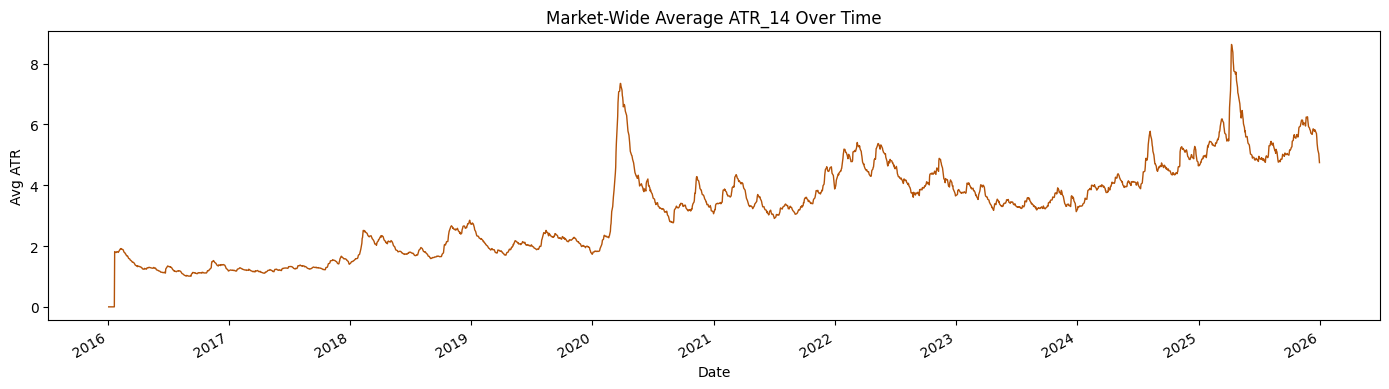

In [101]:
# 8.3 ATR_14 trend (average true range over time)
daily_atr = df.groupby('date')['ATR_14'].mean()
fig, ax = plt.subplots(figsize=(14, 4))
daily_atr.plot(ax=ax, color='#b45309', linewidth=1)
ax.set_title('Market-Wide Average ATR_14 Over Time')
ax.set_xlabel('Date'); ax.set_ylabel('Avg ATR')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

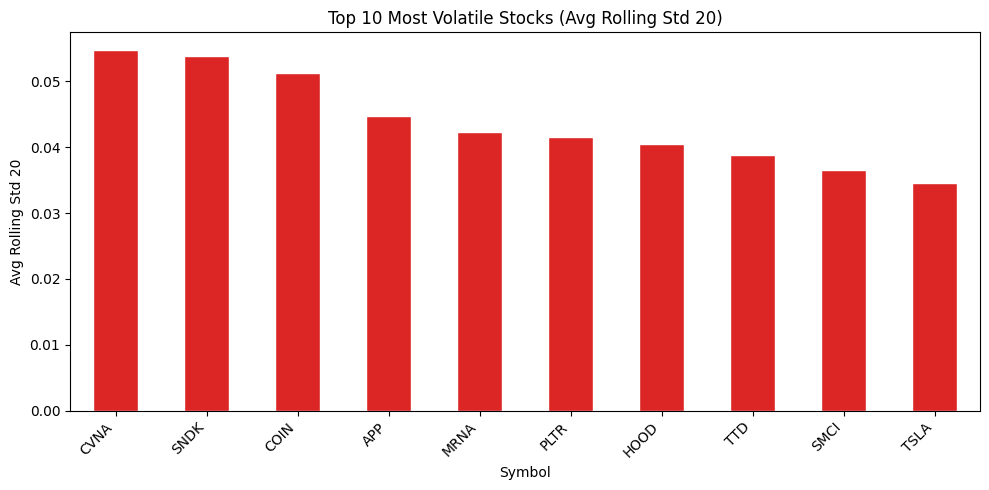

In [102]:
# 8.4 Top 10 most volatile stocks (avg Rolling_Std_20)
top_vol = symbol_stats.sort_values('avg_volatility', ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 5))
top_vol['avg_volatility'].plot(kind='bar', ax=ax, color='#dc2626', edgecolor='white')
ax.set_title('Top 10 Most Volatile Stocks (Avg Rolling Std 20)')
ax.set_ylabel('Avg Rolling Std 20')
ax.set_xlabel('Symbol')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

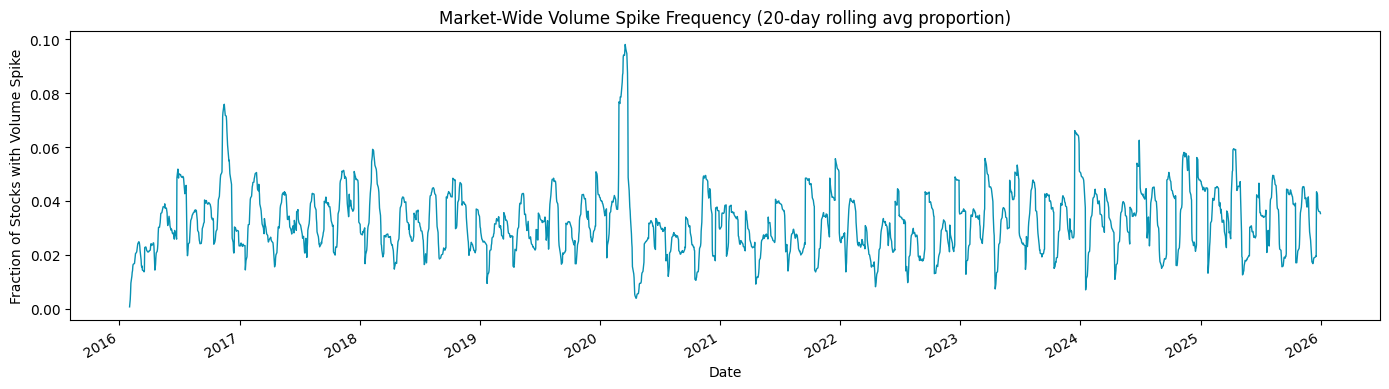

Total volume spikes across all stocks: 39,344


In [103]:
# 8.5 Volume Spike frequency over time
daily_spikes = df.groupby('date')['Volume_Spike'].mean()  # proportion of stocks spiking
fig, ax = plt.subplots(figsize=(14, 4))
daily_spikes.rolling(20).mean().plot(ax=ax, color='#0891b2', linewidth=1)
ax.set_title('Market-Wide Volume Spike Frequency (20-day rolling avg proportion)')
ax.set_xlabel('Date'); ax.set_ylabel('Fraction of Stocks with Volume Spike')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()
print(f"Total volume spikes across all stocks: {df['Volume_Spike'].sum():,}")

## Step:9 Class Distribution/Target Variable analysis

Class distribution:
target
Up (1)      0.5241
Down (0)    0.4759
Name: proportion, dtype: float64


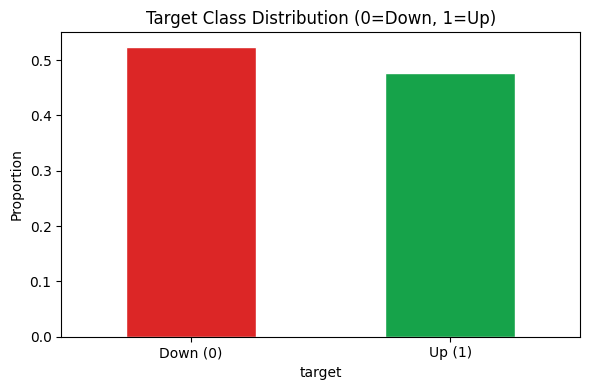

In [104]:
# 9.1 Define target: 1 if next day's close > today's close
df['target'] = (df.groupby('symbol')['close'].shift(-1) > df['close']).astype(float)

class_dist = df['target'].value_counts(normalize=True)
print("Class distribution:")
print(class_dist.rename({0.0: 'Down (0)', 1.0: 'Up (1)'}).round(4))

fig, ax = plt.subplots(figsize=(6, 4))
class_dist.plot(kind='bar', ax=ax, color=['#dc2626', '#16a34a'], edgecolor='white')
ax.set_title('Target Class Distribution (0=Down, 1=Up)')
ax.set_xticklabels(['Down (0)', 'Up (1)'], rotation=0)
ax.set_ylabel('Proportion')
plt.tight_layout()
plt.show()


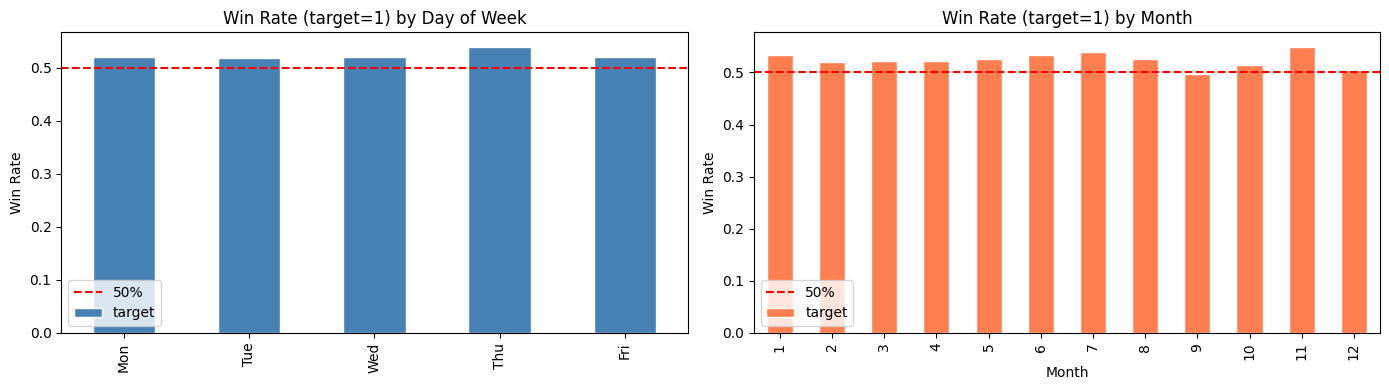

In [105]:
# 9.2 Target distribution by Day of Week and Month
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df.groupby('Day_of_Week')['target'].mean().rename(
    index={0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri'}).plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axhline(0.5, color='red', linestyle='--', label='50%')
axes[0].set_title('Win Rate (target=1) by Day of Week')
axes[0].set_ylabel('Win Rate'); axes[0].legend()
axes[0].set_xlabel('')

df.groupby('Month')['target'].mean().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].axhline(0.5, color='red', linestyle='--', label='50%')
axes[1].set_title('Win Rate (target=1) by Month')
axes[1].set_ylabel('Win Rate'); axes[1].legend()
axes[1].set_xlabel('Month')

plt.tight_layout()
plt.show()

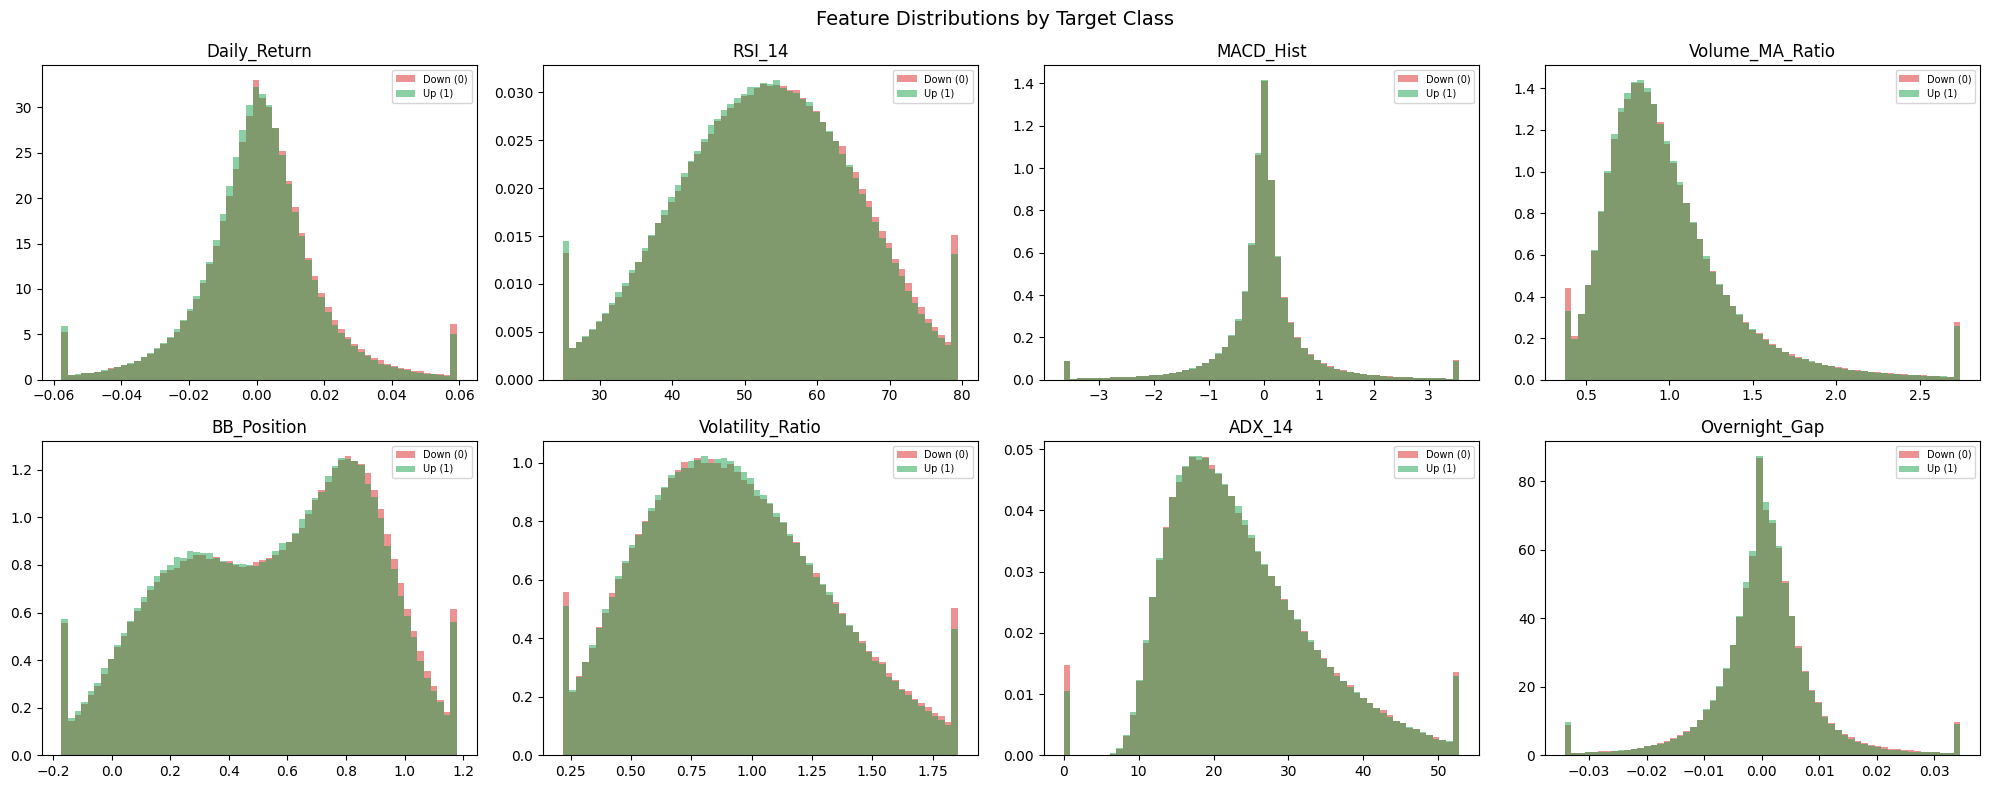

In [106]:
# 9.3 Feature distributions split by target class
split_cols = ['Daily_Return', 'RSI_14', 'MACD_Hist', 'Volume_MA_Ratio',
              'BB_Position', 'Volatility_Ratio', 'ADX_14', 'Overnight_Gap']
split_cols = [c for c in split_cols if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(split_cols):
    lo = df[df['target'] == 0][col].dropna().clip(
        df[col].quantile(0.01), df[col].quantile(0.99))
    hi = df[df['target'] == 1][col].dropna().clip(
        df[col].quantile(0.01), df[col].quantile(0.99))
    axes[i].hist(lo, bins=60, alpha=0.5, color='#dc2626', label='Down (0)', density=True)
    axes[i].hist(hi, bins=60, alpha=0.5, color='#16a34a', label='Up (1)',   density=True)
    axes[i].set_title(col); axes[i].legend(fontsize=7)
plt.suptitle('Feature Distributions by Target Class', fontsize=14)
plt.tight_layout()
plt.show()

Top 20 features by mean difference (Up vs Down days):
OBV_Signal    5.020686e+06
OBV           4.706133e+06
CCI_20       -2.527890e+00
Stoch_K      -7.577700e-01
Williams_R   -7.577700e-01
EMA_12       -6.757800e-01
EMA_26       -6.712300e-01
BB_Upper     -6.704900e-01
SMA_5        -6.265300e-01
SMA_10       -6.174600e-01
VWAP         -5.943800e-01
BB_Mid       -5.813900e-01
SMA_20       -5.813900e-01
Stoch_D      -5.118700e-01
BB_Lower     -4.922900e-01
High_Lag1    -4.891900e-01
Low_Lag1     -4.732100e-01
SMA_50       -4.554800e-01
RSI_14       -3.225500e-01
ROC_10       -1.681100e-01
dtype: float64


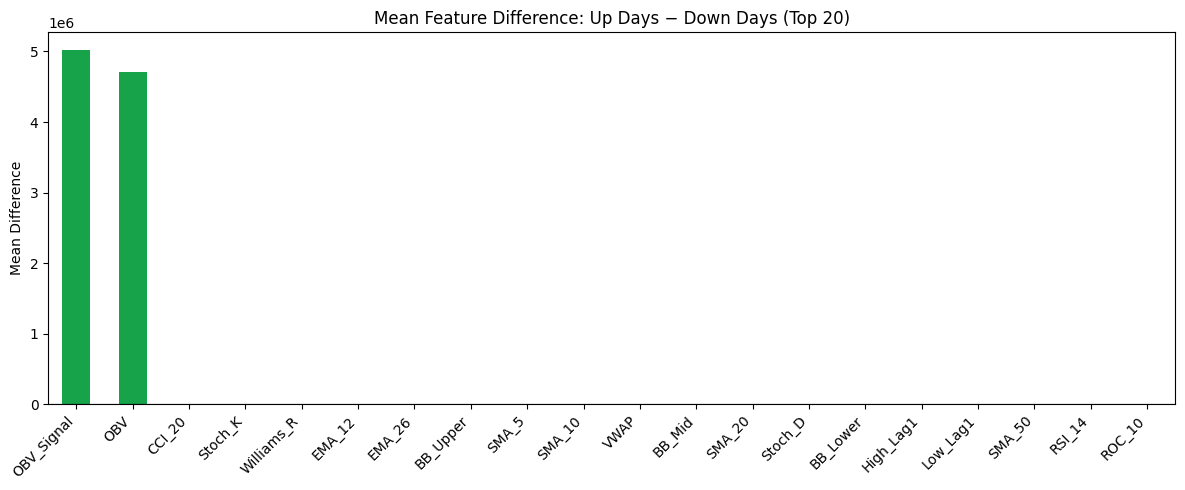

In [107]:
# 9.4 Feature mean difference between Up and Down days
num_cols = df.select_dtypes(include='number').columns.tolist()
exclude  = ['open','high','low','close','volume','target',
            'Day_of_Week','Month','Is_Month_End','Volume_Spike','Consecutive_Up']
feat_cols = [c for c in num_cols if c not in exclude]

mean_up   = df[df['target'] == 1][feat_cols].mean()
mean_down = df[df['target'] == 0][feat_cols].mean()
diff      = (mean_up - mean_down).sort_values(key=abs, ascending=False)

print("Top 20 features by mean difference (Up vs Down days):")
print(diff.head(20).round(5))

fig, ax = plt.subplots(figsize=(12, 5))
diff.head(20).plot(kind='bar', ax=ax,
    color=['#16a34a' if v > 0 else '#dc2626' for v in diff.head(20)])
ax.set_title('Mean Feature Difference: Up Days − Down Days (Top 20)')
ax.set_ylabel('Mean Difference')
ax.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step:10 Data Quality Summary

In [108]:
# 10.1 Core data quality summary
print("          DATA QUALITY SUMMARY")
print("")
print(f"  Total records          : {len(df):>12,}")
print(f"  Total features         : {df.shape[1]:>12,}")
print(f"  Unique stocks          : {df['symbol'].nunique():>12,}")
print(f"  Date range             : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"  Missing values (any col): {df.isnull().any(axis=1).sum():>11,}")
print(f"  Duplicate rows         : {df.duplicated().sum():>12,}")
print(f"  Invalid OHLC rows      : {(df['high'] < df['low']).sum():>12,}")
print(f"  Volume <= 0 rows       : {(df['volume'] <= 0).sum():>12,}")
print(f"  Stocks w/ <90% cover   : {len(incomplete_stocks):>12,}")
print(f"  Volume spike events    : {df['Volume_Spike'].sum():>12,}")
print(f"  Target class balance   : Down={df['target'].mean()*0:.0%}  Up={df['target'].mean():.1%}")


          DATA QUALITY SUMMARY

  Total records          :    1,220,278
  Total features         :           61
  Unique stocks          :          500
  Date range             : 2016-01-04 → 2025-12-31
  Missing values (any col):      27,582
  Duplicate rows         :            0
  Invalid OHLC rows      :            0
  Volume <= 0 rows       :        1,904
  Stocks w/ <90% cover   :           30
  Volume spike events    :       39,344
  Target class balance   : Down=0%  Up=52.4%


In [109]:
# 10.2 Missing value heatmap per feature group
feature_groups = {
    'Price-based' : ['Daily_Return','Overnight_Gap','HL_Range','CO_Spread',
                     'Upper_Shadow','Lower_Shadow','Body_Size'],
    'Trend MAs'   : ['SMA_5','SMA_10','SMA_20','SMA_50','EMA_12','EMA_26',
                     'Price_vs_SMA20','SMA5_vs_SMA20','EMA_Cross'],
    'Momentum'    : ['RSI_14','MACD','MACD_Signal','MACD_Hist','Stoch_K','Stoch_D',
                     'ROC_5','ROC_10','Williams_R','CCI_20','ADX_14'],
    'Volatility'  : ['ATR_14','BB_Upper','BB_Lower','BB_Mid','BB_Width','BB_Position',
                     'Rolling_Std_5','Rolling_Std_20','Volatility_Ratio'],
    'Volume'      : ['Volume_MA_Ratio','OBV','OBV_Signal','Volume_Spike',
                     'VWAP','Price_vs_VWAP','Volume_Return_Corr'],
    'Lagged'      : ['Return_Lag1','Return_Lag2','Return_Lag3',
                     'Volume_Lag1','High_Lag1','Low_Lag1'],
}

print(f"{'Feature Group':<15} {'Total Cols':>10} {'Cols w/ NaN':>12} {'Max NaN %':>10}")
print("-" * 52)
for grp, cols in feature_groups.items():
    avail = [c for c in cols if c in df.columns]
    nan_cols = sum(1 for c in avail if df[c].isnull().any())
    max_pct  = max((df[c].isnull().mean()*100 for c in avail), default=0)
    print(f"  {grp:<13} {len(avail):>10} {nan_cols:>12} {max_pct:>9.2f}%")


Feature Group   Total Cols  Cols w/ NaN  Max NaN %
----------------------------------------------------
  Price-based            7            2      0.04%
  Trend MAs              9            9      2.01%
  Momentum              11           10      1.35%
  Volatility             9            8      0.82%
  Volume                 7            4      0.79%
  Lagged                 6            6      0.82%


In [110]:
# 10.3 Final readiness assessment for EDA and modelling
total_feat = df.shape[1]
nan_free   = df.select_dtypes(include='number').isnull().sum()
ready_feat = (nan_free == 0).sum()
pct_ready  = ready_feat / total_feat * 100

print("\nEDA READINESS ASSESSMENT:")
print(f"  Features with zero NaNs : {ready_feat} / {total_feat}  ({pct_ready:.1f}%)")
print(f"  OHLCV integrity issues  : {(df['high']<df['low']).sum()} rows")
print(f"  Class balance (Up rate) : {df['target'].mean():.4f}")
print(f"  Approx balanced dataset : {'YES' if 0.45 < df['target'].mean() < 0.55 else 'NO'}")



EDA READINESS ASSESSMENT:
  Features with zero NaNs : 20 / 61  (32.8%)
  OHLCV integrity issues  : 0 rows
  Class balance (Up rate) : 0.5241
  Approx balanced dataset : YES


In [111]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1220278 entries, 0 to 1220277
Data columns (total 61 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   symbol              1220278 non-null  str           
 1   date                1220278 non-null  datetime64[ms]
 2   open                1220278 non-null  float64       
 3   high                1220278 non-null  float64       
 4   low                 1220278 non-null  float64       
 5   close               1220278 non-null  float64       
 6   volume              1220278 non-null  int64         
 7   Daily_Return        1219778 non-null  float64       
 8   Overnight_Gap       1219778 non-null  float64       
 9   HL_Range            1220278 non-null  float64       
 10  CO_Spread           1220278 non-null  float64       
 11  Upper_Shadow        1220278 non-null  float64       
 12  Lower_Shadow        1220278 non-null  float64       
 13  Body_Size           122

In [ ]:
output_path = "E:\\Stock-Price-Prediction-using-Advanced-modelling\\data\\3_eda\\filtered_OHLCV.parquet"
df.to_parquet(output_path, index=False, engine='pyarrow')
print(f"DataFrame saved to {output_path}")

DataFrame saved to E:\Stock-Price-Prediction-using-Advanced-modelling\data\3_eda\ffiltered_OHLCV.parquet
